In [1]:
import os, torch
#from torchdiffeq import odeint_adjoint as odeint
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import time
import sys
sys.path.append('../')
from typing import Tuple, Any

%load_ext autoreload
%autoreload 2


import interflow as itf
import interflow.prior as prior
import interflow.fabrics
import interflow.fabrics_extra
import interflow.stochastic_interpolant as stochastic_interpolant
import interflow.realnvp as realnvp
from interflow.unet_velocity import make_lightweight_unet_velocity_2d  # NEW: Import UNet
from torch import autograd
from functorch import jacfwd, vmap


if torch.cuda.is_available():
    print('CUDA available, setting default tensor residence to GPU.')
    itf.util.set_torch_device('cuda')
else:
    print('No CUDA device found!')
print(itf.util.get_torch_device())


print("Torch version:", torch.__version__)

CUDA available, setting default tensor residence to GPU.
cuda
Torch version: 2.5.1


/home/wang6559/.conda/envs/OT_IMM/lib/python3.10/site-packages/torch/__init__.py:1144: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Device] Using: {device} | CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')}")
if device.type == "cuda":
    try:
        print("[Device] GPU:", torch.cuda.get_device_name(0))
        torch.backends.cudnn.benchmark = True
    except Exception as _e:
        print("[Device] GPU name unavailable:", _e)

def move_to(obj, device=device, non_blocking=True):
    """Recursively move tensors in nested containers to device."""
    import torch
    if torch.is_tensor(obj):
        return obj.to(device=device, non_blocking=non_blocking)
    if isinstance(obj, dict):
        return {k: move_to(v, device, non_blocking) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        seq = [move_to(x, device, non_blocking) for x in obj]
        return type(obj)(seq) if isinstance(obj, tuple) else seq
    return obj

print("[Device] Helper move_to() is defined.")

# ============================================================================
# Random seed for reproducibility (matching script configuration)
# ============================================================================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"[Seed] Set random seed to {SEED} for reproducibility")


[Device] Using: cuda | CUDA_VISIBLE_DEVICES=None
[Device] GPU: NVIDIA L40S
[Device] Helper move_to() is defined.
[Seed] Set random seed to 42 for reproducibility


## Utility Functions

In [3]:
def grab(var):
    """Take a tensor off the gpu and convert it to a numpy array on the CPU."""
    return var.detach().cpu().numpy()


def compute_likelihoods(
    b: torch.nn.Module,
    s: torch.nn.Module,
    interpolant: stochastic_interpolant.Interpolant,
    n_save: int,
    n_step: int,
    eps: int,
    bs: int
) -> Tuple[torch.tensor, torch.tensor]:
    """Draw samples from the probability flow and SDE models, and compute likelihoods."""
    
    try:
        # Use simpler Euler method instead of dopri5 for multivariate interpolant
        pflow = stochastic_interpolant.PFlowIntegrator(
            b=b,  
            method='euler',  # Changed from 'dopri5' for stability
            interpolant=interpolant,
            n_step=50  # Reduced steps for speed
        )
        
        x0_tests = base(bs)
        
        logp0 = base.log_prob(x0_tests)  # [bs]
        xfs_pflow, dlogp_pflow = pflow.rollout(x0_tests)  # [n_save x bs x dim], [n_save x bs]
        
        # Handle potential shape issues
        xf_final = xfs_pflow[-1]
        if xf_final.dim() == 3:
            # If shape is [1, bs, dim] or [bs, bs, dim]
            if xf_final.shape[0] == 1:
                xf_final = xf_final.squeeze(0)
            elif xf_final.shape[0] == xf_final.shape[1]:  # Diagonal case
                batch_size = xf_final.shape[0]
                dim = xf_final.shape[2]
                xf_temp = torch.zeros(batch_size, dim, device=xf_final.device)
                for i in range(batch_size):
                    xf_temp[i] = xf_final[i, i]
                xf_final = xf_temp
        
        xf_pflow = grab(xf_final)  # [bs x dim]
        logpx_pflow = logp0 + dlogp_pflow[-1].squeeze()  # [bs]
        
    except Exception as e:
        print(f"Warning: compute_likelihoods failed with error: {e}")
        print("Returning dummy values for this iteration")
        # Return dummy values to avoid training halt
        xf_pflow = np.zeros((bs, 2))
        logpx_pflow = torch.zeros(bs, device=device)
    
    return xf_pflow, logpx_pflow


def log_metrics(
    b: torch.nn.Module,
    s: torch.nn.Module,
    interpolant: stochastic_interpolant.Interpolant,
    n_save: int,
    n_step: int,
    likelihood_bs: int, 
    b_loss: torch.tensor,
    s_loss: torch.tensor,
    loss: torch.tensor,
    b_grad: torch.tensor,
    s_grad: torch.tensor,
    eps: torch.tensor,
    data_dict: dict
) -> None:
    # log loss and gradient data
    b_loss   = grab(b_loss).mean(); data_dict['b_losses'].append(b_loss)
    s_loss   = grab(s_loss).mean(); data_dict['s_losses'].append(s_loss)
    loss     = grab(loss).mean(); data_dict['losses'].append(loss)
    b_grad   = grab(b_grad).mean(); data_dict['b_grads'].append(b_grad)
    s_grad   = grab(s_grad).mean(); data_dict['s_grads'].append(s_grad)

    
    # compute and log likelihood data
    _, _, logpx_pflow = compute_likelihoods(
        b, s, interpolant, n_save, n_step, eps, likelihood_bs)
    
    logpx_pflow = grab(logpx_pflow).mean(); data_dict['logps_pflow'].append(logpx_pflow)
    

def make_plots(
    b: torch.nn.Module,
    s: torch.nn.Module,
    interpolant: stochastic_interpolant.Interpolant,
    n_save: int,
    n_step: int, ## number of sde steps in [0,1]
    likelihood_bs: int,
    counter: int,
    metrics_freq: int,
    eps: torch.tensor,
    data_dict: dict,
    save_path: str = None,  # Add save_path parameter
    epoch: int = None,       # Add epoch parameter for file naming
    width: float = 1.0,
    height: float = 0.1,
) -> None:
    """Make plots to visualize samples and evolution of the likelihood."""
    # compute likelihood and samples for SDE and probability flow.
    print(f"  [make_plots] Computing likelihoods with bs={likelihood_bs}...")
    xf_pflow, logpx_pflow = compute_likelihoods(
        b, s, interpolant, n_save, n_step, eps, likelihood_bs
    )
    print(f"  [make_plots] Likelihood computation complete. Creating plots...")

    ### Create figure with 3 subplots: samples, losses, and v_sq_norm
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Samples from PFlow
    axes[0].hist2d(xf_pflow[:,0], xf_pflow[:,1], bins=100, range=[[-width,width],[-height,height]])
    axes[0].set_title("Samples from PFlow", fontsize=14)
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    # Plot 2: Losses over epochs (linear scale since losses can be negative)
    if 'v_losses' in data_dict and len(data_dict['v_losses']) > 0:
        epochs = np.arange(1, len(data_dict['v_losses']) + 1)
        axes[1].plot(epochs, data_dict['v_losses'], label='v_loss', color='blue', linewidth=2)
        if 'flow_losses' in data_dict and len(data_dict['flow_losses']) > 0:
            axes[1].plot(epochs, data_dict['flow_losses'], label='flow_loss', color='red', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].set_title('Training Losses', fontsize=14)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        # Add a horizontal line at y=0 for reference
        axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        # No log scale since losses can be negative

    # Plot 3: v_squared_norm over epochs
    if 'v_squared_norm' in data_dict and len(data_dict['v_squared_norm']) > 0:
        epochs = np.arange(1, len(data_dict['v_squared_norm']) + 1)
        axes[2].plot(epochs, data_dict['v_squared_norm'], color='green', linewidth=2)
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel(r'$\mathbb{E}[|v_t|^2]$')
        axes[2].set_title('Velocity Field Squared Norm', fontsize=14)
        axes[2].grid(True, alpha=0.3)

    # Add overall title
    if epoch is not None:
        fig.suptitle(f"Epoch {epoch} | ε = {grab(eps)}", fontsize=16, y=1.02)
    else:
        fig.suptitle(f"ε = {grab(eps)}", fontsize=16, y=1.02)

    plt.tight_layout()

    # Save the figure if save_path is provided
    if save_path is not None:
        if epoch is not None:
            filename = f"{save_path}/plots_epoch_{epoch:04d}.png"
        else:
            filename = f"{save_path}/plots.png"
        plt.savefig(filename, dpi=100, bbox_inches='tight')
        print(f"  [make_plots] Saved plot to {filename}")

    plt.show()
    print(f"  [make_plots] Plot display complete.")
    

def estimate_v_squared_norm(
      v: torch.nn.Module,
      interpolant,
      base,
      target,
      n_samples: int = 1000,
      batch_size: int = 100,
      device = None
  ) -> float:
    """
    Monte Carlo estimate of E_{t,x_0,x_1}[|v_t(I_t(x_0,x_1))|^2].

    Draws mini-batches of (x_0, x_1, t) with t ~ U[0,1] and averages |v_t|^2.
    Handles arbitrary sample counts without bias toward boundary times.
    """
    if n_samples <= 0:
        return 0.0

    batch_size = max(1, batch_size)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    v_was_training = v.training
    flow_model = getattr(interpolant, 'flow_model', None)
    flow_was_training = flow_model.training if flow_model is not None else None

    v.eval()
    if flow_model is not None:
        flow_model.eval()

    total_sq = 0.0
    total_count = 0
    remaining = n_samples

    with torch.no_grad():
        while remaining > 0:
            current_bs = min(batch_size, remaining)
            t = torch.rand(1, device=device)
            x0s = base(current_bs).to(device)
            x1s = target(current_bs).to(device)

            xts = interpolant.calc_xt(t, x0s, x1s)
            if isinstance(xts, tuple):
                xts = xts[0]
            
            # Handle multivariate interpolant shape [bs, bs, dim]
            if xts.dim() == 3 and xts.shape[0] == xts.shape[1]:
                batch_sz = xts.shape[0]
                dim = xts.shape[2]
                xts_diag = torch.zeros(batch_sz, dim, device=xts.device)
                for i in range(batch_sz):
                    xts_diag[i] = xts[i, i]
                xts = xts_diag

            vts = v(xts, t)
            batch_sq = vts.pow(2).sum(dim=-1)

            total_sq += batch_sq.sum().item()
            total_count += batch_sq.numel()
            remaining -= current_bs

    if v_was_training:
        v.train()
    else:
        v.eval()

    if flow_model is not None:
        if flow_was_training:
            flow_model.train()
        else:
            flow_model.eval()

    return float(total_sq / total_count) if total_count else 0.0

def estimate_v_squared_norm_grid(
      v: torch.nn.Module,
      interpolant,
      base,
      target,
      n_samples: int = 1000,
      n_time_points: int = 10,  # Grid resolution
      device=None
  ) -> float:
      """
      Use fixed time grid, sample uniformly from (x0, x1) at each time.
      More stable and efficient in practice.
      """
      if device is None:
          device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

      v_was_training = v.training
      flow_model = getattr(interpolant, 'flow_model', None)
      flow_was_training = flow_model.training if flow_model is not None else None

      v.eval()
      if flow_model is not None:
          flow_model.eval()

      # Fixed time grid
      time_grid = torch.linspace(0, 1, n_time_points, device=device)
      samples_per_time = n_samples // n_time_points

      total_sq = 0.0
      total_count = 0

      with torch.no_grad():
          for t_val in time_grid:
              t = t_val.unsqueeze(0)  # [1]

              # Sample at this time point
              x0s = base(samples_per_time).to(device)
              x1s = target(samples_per_time).to(device)

              xts = interpolant.calc_xt(t, x0s, x1s)
              if isinstance(xts, tuple):
                  xts = xts[0]
              
              # Handle multivariate interpolant shape [bs, bs, dim]
              if xts.dim() == 3 and xts.shape[0] == xts.shape[1]:
                  batch_sz = xts.shape[0]
                  dim = xts.shape[2]
                  xts_diag = torch.zeros(batch_sz, dim, device=xts.device)
                  for i in range(batch_sz):
                      xts_diag[i] = xts[i, i]
                  xts = xts_diag

              vts = v(xts, t)
              batch_sq = vts.pow(2).sum(dim=-1)

              total_sq += batch_sq.sum().item()
              total_count += batch_sq.numel()

      # Restore training mode
      if v_was_training:
          v.train()
      if flow_model is not None and flow_was_training:
          flow_model.train()

      return float(total_sq / total_count) if total_count else 0.0

def estimate_partial_t_v_squared_norm(
      v: torch.nn.Module,
      interpolant,
      base,
      target,
      n_samples: int = 1000,
      batch_size: int = 100,
      device = None
  ) -> float:
    """
    Monte Carlo estimate of E_{t,x_0,x_1}[|∂_t v_t(I_t(x_0,x_1), t)|^2].

    Uses jacobian-vector products to obtain ∂_t v_t efficiently for each batch.
    """
    if n_samples <= 0:
        return 0.0

    batch_size = max(1, batch_size)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    v_was_training = v.training
    flow_model = getattr(interpolant, 'flow_model', None)
    flow_was_training = flow_model.training if flow_model is not None else None

    v.eval()
    if flow_model is not None:
        flow_model.eval()

    total_sq = 0.0
    total_count = 0
    remaining = n_samples

    while remaining > 0:
        current_bs = min(batch_size, remaining)

        x0s = base(current_bs).to(device)
        x1s = target(current_bs).to(device)
        t = torch.rand(1, device=device)
        t.requires_grad_(True)

        def v_at_time(t_input: torch.Tensor) -> torch.Tensor:
            if t_input.dim() == 0:
                t_input = t_input.unsqueeze(0)
            xts_local = interpolant.calc_xt(t_input, x0s, x1s)
            if isinstance(xts_local, tuple):
                xts_local = xts_local[0]
            
            # Handle multivariate shape
            if xts_local.dim() == 3 and xts_local.shape[0] == xts_local.shape[1]:
                batch_sz = xts_local.shape[0]
                dim = xts_local.shape[2]
                xts_diag = torch.zeros(batch_sz, dim, device=xts_local.device)
                for i in range(batch_sz):
                    xts_diag[i] = xts_local[i, i]
                xts_local = xts_diag
            
            return v(xts_local, t_input)

        _, dv_dt = torch.autograd.functional.jvp(
            v_at_time,
            t,
            torch.ones_like(t),
            create_graph=False,
            strict=False,
        )

        if dv_dt.dim() == 1:
            dv_dt = dv_dt.unsqueeze(0)

        batch_sq = dv_dt.pow(2).sum(dim=-1).detach()

        total_sq += batch_sq.sum().item()
        total_count += batch_sq.numel()
        remaining -= current_bs

    if v_was_training:
        v.train()
    else:
        v.eval()

    if flow_model is not None:
        if flow_was_training:
            flow_model.train()
        else:
            flow_model.eval()

    return float(total_sq / total_count) if total_count else 0.0


In [4]:
import math


def total_grad_norm(params):
    norms = []
    for p in params:
        if p.grad is not None:
            norms.append(p.grad.detach().pow(2).sum())
    if not norms:
        return 0.0
    return torch.stack(norms).sum().sqrt().item()


def set_requires_grad(module, flag: bool):
    for p in module.parameters():
        p.requires_grad_(flag)


def _as_float_list(values, default, dim=None):
    if values is None:
        if dim is None:
            return [default]
        return [default] * dim
    if torch.is_tensor(values):
        vals = values.detach().cpu().flatten().tolist()
    elif isinstance(values, (list, tuple)):
        vals = [float(v) for v in values]
    else:
        vals = [float(values)]
    if dim is not None and len(vals) < dim:
        fill_val = vals[-1] if vals else default
        vals = vals + [fill_val] * (dim - len(vals))
    return vals


def _compute_static_kink_summary(matrix_cfg, eps: float = 1e-4):
    if not isinstance(matrix_cfg, dict):
        return []
    if matrix_cfg.get('coefficient_type', 'polynomial') != 'polynomial':
        return []

    p_vals = _as_float_list(matrix_cfg.get('exponent_p'), 1.0)
    q_vals = _as_float_list(matrix_cfg.get('exponent_q'), 1.0, dim=len(p_vals))
    dim = max(len(p_vals), len(q_vals))
    p_vals = _as_float_list(matrix_cfg.get('exponent_p'), 1.0, dim=dim)
    q_vals = _as_float_list(matrix_cfg.get('exponent_q'), 1.0, dim=dim)

    events = []
    for p_val, q_val in zip(p_vals, q_vals):
        p = float(p_val)
        q = float(q_val)

        if p < 1.0 - 1e-8:
            events.append((eps, 1.0 + (1.0 - p)))
        elif p > 1.0 + 1e-8:
            events.append((1.0 - eps, p - 1.0))

        if q < 1.0 - 1e-8:
            events.append((eps, 1.0 + (1.0 - q)))
        elif q > 1.0 + 1e-8:
            events.append((1.0 - eps, q - 1.0))

        if abs(q - p) > 1e-8:
            ratio = max(p, 1e-6) / max(q, 1e-6)
            exponent = 1.0 / (q - p)
            t_switch = math.exp(exponent * math.log(max(ratio, 1e-6)))
            events.append((max(min(t_switch, 1.0 - eps), eps), 0.5 * (p + q)))
        else:
            events.append((0.5, p))

        left, right = eps, 1.0 - eps
        for _ in range(25):
            mid = 0.5 * (left + right)
            f_mid = (1.0 - mid ** p) - mid ** q
            if f_mid > 0.0:
                left = mid
            else:
                right = mid
        mid = 0.5 * (left + right)
        events.append((mid, p + q))

    events.sort(key=lambda item: item[0])
    merged = []
    for loc, weight in events:
        loc = max(min(loc, 1.0 - eps), eps)
        if not merged or abs(loc - merged[-1][0]) > 5e-3:
            merged.append([loc, weight])
        else:
            merged[-1][1] += weight
    return [(float(loc), float(weight)) for loc, weight in merged]


def _get_beta_parameters_from_matrix_config(matrix_cfg):
    if not isinstance(matrix_cfg, dict):
        return 1.0, 1.0
    if matrix_cfg.get('coefficient_type', 'polynomial') != 'polynomial':
        return 1.0, 1.0

    p_vals = _as_float_list(matrix_cfg.get('exponent_p'), 1.0)
    q_vals = _as_float_list(matrix_cfg.get('exponent_q'), 1.0)

    alpha = float(max(max(p_vals), 1.0))
    beta = float(max(max(q_vals), 1.0))
    return alpha, beta


def _prepare_exponent_tensors(matrix_cfg, data_dim, device, dtype):
    if data_dim is None:
        raise ValueError('data_dim must be provided to prepare exponent tensors')

    def _to_tensor(values):
        vals = _as_float_list(values, 1.0, dim=data_dim)
        tensor = torch.tensor(vals, device=device, dtype=dtype)
        if tensor.numel() > data_dim:
            tensor = tensor[:data_dim]
        return tensor

    if not isinstance(matrix_cfg, dict):
        ones = torch.ones(data_dim, device=device, dtype=dtype)
        return ones, ones
    if matrix_cfg.get('coefficient_type', 'polynomial') != 'polynomial':
        ones = torch.ones(data_dim, device=device, dtype=dtype)
        return ones, ones

    p_tensor = _to_tensor(matrix_cfg.get('exponent_p'))
    q_tensor = _to_tensor(matrix_cfg.get('exponent_q'))
    return p_tensor, q_tensor


def _compute_batch_kink_times(
    x0_batch,
    x1_batch,
    p_exponents,
    q_exponents,
    eps: float = 1e-6,
    max_points: int = 4096,
):
    if x0_batch is None or x1_batch is None:
        return None
    if p_exponents is None or q_exponents is None:
        return None

    device = x0_batch.device
    dtype = x0_batch.dtype

    p = p_exponents.to(device=device, dtype=dtype).view(1, -1)
    q = q_exponents.to(device=device, dtype=dtype).view(1, -1)

    x0_abs = x0_batch.abs() + eps
    x1_abs = x1_batch.abs() + eps

    diff = q - p
    mask = diff.abs() > 1e-6
    inv_diff = torch.where(mask, 1.0 / diff, torch.zeros_like(diff))

    safe_ratio = (p * x0_abs) / (q * x1_abs)
    safe_ratio = safe_ratio.clamp(min=eps, max=1.0 / eps)
    t_switch = torch.exp(inv_diff * torch.log(safe_ratio))
    t_switch = torch.where(mask, t_switch, torch.full_like(t_switch, 0.5))
    t_switch = t_switch.clamp(min=eps, max=1.0 - eps)

    left = torch.full_like(x0_abs, eps)
    right = torch.full_like(x0_abs, 1.0 - eps)
    for _ in range(8):
        mid = 0.5 * (left + right)
        mid_pow_p = mid.pow(p)
        mid_pow_q = mid.pow(q)
        balance = x0_abs * (1.0 - mid_pow_p) - x1_abs * mid_pow_q
        left = torch.where(balance > 0, mid, left)
        right = torch.where(balance > 0, right, mid)
    t_balance = 0.5 * (left + right)

    times = torch.cat([t_switch.reshape(-1), t_balance.reshape(-1)], dim=0)
    mask_valid = (times > 5 * eps) & (times < 1.0 - 5 * eps)
    times = times[mask_valid]
    if times.numel() == 0:
        return None

    times = times.unique()
    if times.numel() > max_points:
        idx = torch.randperm(times.numel(), device=device)[:max_points]
        times = times[idx]
    return times.detach()


def _sample_mixed_times_and_weights(
    bs,
    device,
    dtype,
    alpha,
    beta,
    mix_prob=0.7,
    keepdim=False,
    strategy='enhanced_beta_mixture',
    x0_batch=None,
    x1_batch=None,
    p_exponents=None,
    q_exponents=None,
    kink_delta=0.03,
    max_kink_points=2048,
):
    if strategy not in {'original', 'enhanced_beta_mixture'}:
        raise ValueError(f"Unknown strategy: {strategy}")

    if strategy == 'original':
        alpha_t = torch.tensor(alpha, device=device, dtype=dtype)
        beta_t = torch.tensor(beta, device=device, dtype=dtype)
        beta_dist = torch.distributions.Beta(alpha_t, beta_t)
        beta_samples = beta_dist.sample((bs,)).to(device=device, dtype=dtype)
        uniform_samples = torch.rand(bs, device=device, dtype=dtype)
        use_beta = torch.rand(bs, device=device) < mix_prob
        samples = torch.where(use_beta, beta_samples, uniform_samples)
        eps = torch.finfo(dtype).eps
        samples_clamped = samples.clamp(min=eps, max=1.0 - eps)
        beta_pdf = torch.exp(beta_dist.log_prob(samples_clamped))
        mixture_pdf = mix_prob * beta_pdf + (1.0 - mix_prob)
        mixture_pdf = mixture_pdf.clamp_min(eps)
        weights = mixture_pdf.reciprocal().detach()
        if keepdim:
            samples = samples.unsqueeze(-1)
            weights = weights.unsqueeze(-1)
        return samples, weights

    eps = torch.finfo(dtype).eps
    kink_times = _compute_batch_kink_times(
        x0_batch,
        x1_batch,
        p_exponents,
        q_exponents,
        eps=max(eps, 1e-6),
        max_points=max_kink_points,
    )
    if kink_times is not None and kink_times.numel() > 0:
        kink_times = kink_times.to(device=device, dtype=dtype)
        interior_mask = (kink_times > kink_delta) & (kink_times < 1.0 - kink_delta)
        kink_times = kink_times[interior_mask]
        if kink_times.numel() == 0:
            kink_times = None
    else:
        kink_times = None

    w_alpha = 0.25 + (0.15 if alpha > 2.0 else 0.0)
    w_beta = 0.25 + (0.15 if beta > 2.0 else 0.0)
    w_uniform = max(0.1, 0.3 - 0.1 * mix_prob)
    weights_list = [w_alpha, w_beta, w_uniform]

    if kink_times is not None:
        w_kink = 0.3 + 0.1 * mix_prob
        weights_list.append(w_kink)
    else:
        weights_list[2] += 0.3 + 0.1 * mix_prob

    component_weights = torch.tensor(weights_list, device=device, dtype=dtype)
    component_weights = torch.clamp(component_weights, min=1e-6)
    component_weights = component_weights / component_weights.sum()

    component_choices = torch.multinomial(component_weights, bs, replacement=True)
    samples = torch.zeros(bs, dtype=dtype, device=device)

    beta_dist0 = torch.distributions.Beta(
        torch.tensor(alpha, device=device, dtype=dtype),
        torch.tensor(1.0, device=device, dtype=dtype),
    )
    beta_dist1 = torch.distributions.Beta(
        torch.tensor(1.0, device=device, dtype=dtype),
        torch.tensor(beta, device=device, dtype=dtype),
    )

    mask0 = component_choices == 0
    n0 = int(mask0.sum().item())
    if n0 > 0:
        samples[mask0] = beta_dist0.sample((n0,)).to(device=device, dtype=dtype)

    mask1 = component_choices == 1
    n1 = int(mask1.sum().item())
    if n1 > 0:
        samples[mask1] = beta_dist1.sample((n1,)).to(device=device, dtype=dtype)

    mask2 = component_choices == 2
    n2 = int(mask2.sum().item())
    if n2 > 0:
        samples[mask2] = torch.rand(n2, device=device, dtype=dtype)

    if kink_times is not None:
        mask3 = component_choices == 3
        n3 = int(mask3.sum().item())
        if n3 > 0:
            idx = torch.randint(0, kink_times.numel(), (n3,), device=device)
            centres = kink_times[idx]
            noise = (torch.rand(n3, device=device, dtype=dtype) - 0.5) * (2.0 * kink_delta)
            samples[mask3] = (centres + noise).clamp(min=eps, max=1.0 - eps)

    clamped = samples.clamp(min=eps, max=1.0 - eps)
    pdf = torch.zeros_like(clamped)

    pdf += component_weights[0] * torch.exp(beta_dist0.log_prob(clamped))
    pdf += component_weights[1] * torch.exp(beta_dist1.log_prob(clamped))
    pdf += component_weights[2]

    if kink_times is not None:
        kink_weight = component_weights[3]
        if kink_times.numel() > 0:
            distances = torch.abs(clamped.unsqueeze(-1) - kink_times.unsqueeze(0))
            support = (distances <= kink_delta).to(dtype)
            normaliser = 2.0 * kink_delta * float(kink_times.numel())
            kink_pdf = torch.zeros_like(clamped) if normaliser == 0.0 else support.sum(-1) / normaliser
        else:
            kink_pdf = torch.zeros_like(clamped)
        pdf += kink_weight * kink_pdf

    weights = (pdf.clamp_min(eps)).reciprocal().detach()

    if keepdim:
        samples = samples.unsqueeze(-1)
        weights = weights.unsqueeze(-1)

    return samples, weights




def train_step(
    bs: int,
    interpolant: stochastic_interpolant.Interpolant,
    v: torch.nn.Module,
    opt_v: torch.optim.Optimizer,
    opt_flow: torch.optim.Optimizer,
    sched_v: torch.optim.lr_scheduler._LRScheduler,
    sched_flow: torch.optim.lr_scheduler._LRScheduler,
    n_inner: int = 1,
    n_outer: int = 1,
    reuse_batch: bool = True,
    clip_v: float = 1.0,
    clip_flow: float = 1.0,
    device: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_v_only: bool = False,
    mixed_step: int = 0,
    base_fn=None,
    target_fn=None,
    base_kwargs=None,
    target_kwargs=None,
    matrix_cfg=None,
):
    'Single training step with kink-aware time sampling.'
    if base_fn is None:
        base_fn = globals().get('base')
    if target_fn is None:
        target_fn = globals().get('target', globals().get('target_rhombus'))
    base_kwargs = {} if base_kwargs is None else base_kwargs
    target_kwargs = {} if target_kwargs is None else target_kwargs

    if hasattr(interpolant, 'set_step'):
        interpolant.set_step(mixed_step)

    v.train()
    if hasattr(interpolant, 'flow_model'):
        interpolant.flow_model.train()

    loss_fn_sample = globals().get('loss_fn_v_samplewise')
    if loss_fn_sample is None:
        loss_fn_sample = stochastic_interpolant.make_batch_loss(
            stochastic_interpolant.losses['one-sided-v'],
            method='shared',
        )
        globals()['loss_fn_v_samplewise'] = loss_fn_sample

    cfg_for_beta = matrix_cfg if matrix_cfg is not None else globals().get('matrix_config')
    alpha_param, beta_param = _get_beta_parameters_from_matrix_config(cfg_for_beta)
    mix_prob = 0.7
    if isinstance(cfg_for_beta, dict):
        mix_prob = float(cfg_for_beta.get('t_mix_prob', mix_prob))
        kink_delta = float(cfg_for_beta.get('kink_delta', 0.05))
    else:
        kink_delta = 0.05

    shared_ts = None
    shared_weights = None
    shared_x0 = None
    shared_x1 = None
    shared_p_exponents = None
    shared_q_exponents = None

    if reuse_batch:
        shared_x0 = base_fn(bs, **base_kwargs).to(device)
        shared_x1 = target_fn(bs, **target_kwargs).to(device)
        data_dtype = shared_x0.dtype
        data_dim = shared_x0.shape[1]
        shared_p_exponents, shared_q_exponents = _prepare_exponent_tensors(
            cfg_for_beta,
            data_dim,
            shared_x0.device,
            data_dtype,
        )
        shared_ts, shared_weights = _sample_mixed_times_and_weights(
            bs,
            shared_x0.device,
            data_dtype,
            alpha_param,
            beta_param,
            mix_prob=mix_prob,
            strategy='enhanced_beta_mixture',
            keepdim=True,
            x0_batch=shared_x0,
            x1_batch=shared_x1,
            p_exponents=shared_p_exponents,
            q_exponents=shared_q_exponents,
            kink_delta=kink_delta,
        )

    if hasattr(interpolant, 'flow_model'):
        set_requires_grad(interpolant.flow_model, False)
    set_requires_grad(v, True)

    loss_v = torch.tensor(0.0, device=device)
    v_grad_val = 0.0

    for _ in range(n_inner):
        if not reuse_batch:
            x0s = base_fn(bs, **base_kwargs).to(device)
            x1s = target_fn(bs, **target_kwargs).to(device)
            data_dtype = x0s.dtype
            data_dim = x0s.shape[1]
            p_exponents_batch, q_exponents_batch = _prepare_exponent_tensors(
                cfg_for_beta,
                data_dim,
                x0s.device,
                data_dtype,
            )
            ts_batch, weights_batch = _sample_mixed_times_and_weights(
                bs,
                x0s.device,
                data_dtype,
                alpha_param,
                beta_param,
                mix_prob=mix_prob,
                strategy='enhanced_beta_mixture',
                keepdim=True,
                x0_batch=x0s,
                x1_batch=x1s,
                p_exponents=p_exponents_batch,
                q_exponents=q_exponents_batch,
                kink_delta=kink_delta,
            )
        else:
            x0s = shared_x0
            x1s = shared_x1
            ts_batch = shared_ts
            weights_batch = shared_weights

        opt_v.zero_grad(set_to_none=True)
        per_sample_loss = loss_fn_sample(v, x0s, x1s, ts_batch, interpolant)
        weights = weights_batch.to(per_sample_loss.device, per_sample_loss.dtype)
        loss_v = (per_sample_loss * weights).mean()
        loss_v.backward()

        if clip_v is not None and clip_v < float('inf'):
            torch.nn.utils.clip_grad_norm_(v.parameters(), clip_v)
        v_grad_val = total_grad_norm(v.parameters())

        opt_v.step()
        sched_v.step()

    has_flow_params = False
    if hasattr(interpolant, 'flow_model'):
        flow_params = list(interpolant.flow_model.parameters())
        has_flow_params = len(flow_params) > 0

    if not train_v_only and has_flow_params and opt_flow is not None:
        set_requires_grad(v, False)
        set_requires_grad(interpolant.flow_model, True)

        loss_flow = torch.tensor(0.0, device=device)
        flow_grad_val = 0.0

        for _ in range(n_outer):
            if not reuse_batch:
                x0s = base_fn(bs, **base_kwargs).to(device)
                x1s = target_fn(bs, **target_kwargs).to(device)
                data_dtype = x0s.dtype
                data_dim = x0s.shape[1]
                p_exponents_batch, q_exponents_batch = _prepare_exponent_tensors(
                    cfg_for_beta,
                    data_dim,
                    x0s.device,
                    data_dtype,
                )
                ts_batch, weights_batch = _sample_mixed_times_and_weights(
                    bs,
                    x0s.device,
                    data_dtype,
                    alpha_param,
                    beta_param,
                    mix_prob=mix_prob,
                    strategy='enhanced_beta_mixture',
                    keepdim=True,
                    x0_batch=x0s,
                    x1_batch=x1s,
                    p_exponents=p_exponents_batch,
                    q_exponents=q_exponents_batch,
                    kink_delta=kink_delta,
                )
            else:
                x0s = shared_x0
                x1s = shared_x1
                ts_batch = shared_ts
                weights_batch = shared_weights

            opt_flow.zero_grad(set_to_none=True)
            per_sample_loss = loss_fn_sample(v, x0s, x1s, ts_batch, interpolant)
            weights = weights_batch.to(per_sample_loss.device, per_sample_loss.dtype)
            loss_flow = (per_sample_loss * weights).mean()

            (-loss_flow).backward()

            if clip_flow is not None and clip_flow < float('inf'):
                torch.nn.utils.clip_grad_norm_(interpolant.flow_model.parameters(), clip_flow)
            flow_grad_val = total_grad_norm(interpolant.flow_model.parameters())

            opt_flow.step()
            if sched_flow is not None:
                sched_flow.step()

        set_requires_grad(v, True)
        set_requires_grad(interpolant.flow_model, True)

        return loss_v.detach(), loss_flow.detach(), torch.tensor(v_grad_val), torch.tensor(flow_grad_val)

    set_requires_grad(v, True)
    if hasattr(interpolant, 'flow_model'):
        set_requires_grad(interpolant.flow_model, True)

    return loss_v.detach(), torch.tensor(0.0, device=device), torch.tensor(v_grad_val), torch.tensor(0.0, device=device)



## Target

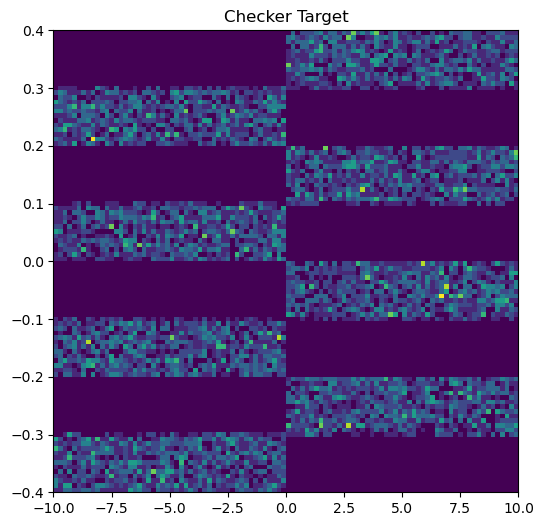

Batch Shape: (10000, 2)


In [5]:
ndim = 2
def target(bs):
    x1 = torch.rand(bs, dtype=torch.float32) * 4 - 2
    x2_ = torch.rand(bs, dtype=torch.float32) - torch.randint(2, (bs,), dtype=torch.float32) * 2
    x2 = x2_ + (torch.floor(x1) % 2)
    return (torch.cat([x1[:, None], x2[:, None]], 1) * 2)

def target_rect(bs,
                w=10.0, h=0.1,          # rectangle (tile) width & height
                layers_x=2, layers_y=4, # how many tiles across (x) and down (y) in the checker
                scale=1.0,              # final global scaling (like your *2)
                device=None, dtype=None):
    """
    Rectangular checkerboard with adjustable aspect ratio and number of layers.

    - Tiles are width w and height h.
    - layers_x, layers_y control how many tiles we place horizontally/vertically.
    - Classic checker staggering: every odd column is shifted by +h.
    - Output is centered around (0,0) and then scaled by `scale`.
    """
    if device is None:
        device = torch.device('cpu')
    if dtype is None:
        dtype = torch.get_default_dtype()

    # choose a column and a vertical "base strip"
    col = torch.randint(layers_x, (bs,), device=device)
    base_row = torch.randint(layers_y, (bs,), device=device)

    # x within the chosen column tile
    x_in = torch.rand(bs, dtype=dtype, device=device) * w
    x = (col.to(dtype) + x_in / w) * w  # in [0, layers_x*w)

    # y within a checker tile, staggered by column parity
    y_in = torch.rand(bs, dtype=dtype, device=device) * h
    # rows span height 2*h per pair because of staggering (checker alternation)
    y = (base_row.to(dtype) * 2.0 * h) + ((col % 2).to(dtype) * h) + y_in  # in [0, 2*layers_y*h)

    # center to ~zero and scale
    x = x - (layers_x * w) / 2.0
    y = y - (layers_y * h)
    out = torch.stack([x, y], dim=1) * scale
    return out


def target_rhombus(bs,
                   s=1.0,                 # side length of the rhombus (both edges equal)
                   angle_deg=10.0,        # interior angle between edges a and b (0<angle<180, != 0/180)
                   layers_x=4,            # how many tiles along the 'a' direction
                   layers_y=4,            # how many (checker) pairs along the 'b' direction
                   scale=2.0,
                   device=None, dtype=None):
    """
    True rhombus checkerboard sampler.

    Construction:
      - Lattice edges: a and b with |a|=|b|=s and angle `angle_deg` between them.
      - Checker staggering: along b, every odd a-column is shifted by +b/2 (i%2).
      - Indices: u in [0, layers_x), v in [0, 2*layers_y) with parity offset.
      - We sample uniformly inside a single rhombus cell by adding u_in, v_in ∈ [0,1).

    Output:
      Tensor of shape [bs, 2].
    """
    if device is None:
        device = torch.device('cpu')
    if dtype is None:
        dtype = torch.get_default_dtype()

    # Integer tile indices for the checker tiling
    i = torch.randint(layers_x, (bs,), device=device)           # column along a
    j = torch.randint(layers_y, (bs,), device=device)           # row-pair along b

    # Uniform offsets inside a rhombus cell
    u_in = torch.rand(bs, device=device, dtype=dtype)           # along a
    v_in = torch.rand(bs, device=device, dtype=dtype)           # along b

    # Staggering to make a checker: v steps by 2, with +1 for odd columns
    u = i.to(dtype) + u_in                                      # [0, layers_x)
    v = (2 * j + (i % 2)).to(dtype) + v_in                      # [0, 2*layers_y)

    # Build rhombus lattice basis (equal side lengths, non-orthogonal)
    theta = math.radians(angle_deg)
    a = torch.tensor([s, 0.0], device=device, dtype=dtype)                      # |a|=s
    b = torch.tensor([s * math.cos(theta), s * math.sin(theta)],                # |b|=s
                     device=device, dtype=dtype)

    # Center the cloud approximately at the origin
    u_c = layers_x / 2.0
    v_c = layers_y       # because v spans 2*layers_y "b-steps"
    pts = (u - u_c).unsqueeze(1) * a + (v - v_c).unsqueeze(1) * b

    return pts * scale

def target_parallelogram(bs,
                         len_a=1,           # length of first side
                         len_b=5.0,           # length of second side
                         angle_deg=60.0,      # interior angle between edges a and b (0<angle<180, != 0/180)
                         layers_x=2,          # how many tiles along the 'a' direction
                         layers_y=3,          # how many (checker) pairs along the 'b' direction
                         scale=1.0,
                         device=None, dtype=None):
    """
    Parallelogram checkerboard sampler with independent control of two side lengths.

    Construction:
      - Lattice edges: a and b with |a|=len_a, |b|=len_b and angle `angle_deg` between them.
      - Checker staggering: along b, every odd a-column is shifted by +b/2 (i%2).
      - Indices: u in [0, layers_x), v in [0, 2*layers_y) with parity offset.
      - We sample uniformly inside a single parallelogram cell by adding u_in, v_in ∈ [0,1).

    Parameters:
      - len_a: length of the first (horizontal-ish) side
      - len_b: length of the second side
      - angle_deg: angle between the two sides (0 < angle < 180)
      - layers_x, layers_y: number of tiles in each direction
      - scale: global scaling factor applied at the end

    Output:
      Tensor of shape [bs, 2].
    """
    if device is None:
        device = torch.device('cpu')
    if dtype is None:
        dtype = torch.get_default_dtype()

    # Integer tile indices for the checker tiling
    i = torch.randint(layers_x, (bs,), device=device)           # column along a
    j = torch.randint(layers_y, (bs,), device=device)           # row-pair along b

    # Uniform offsets inside a parallelogram cell
    u_in = torch.rand(bs, device=device, dtype=dtype)           # along a
    v_in = torch.rand(bs, device=device, dtype=dtype)           # along b

    # Staggering to make a checker: v steps by 2, with +1 for odd columns
    u = i.to(dtype) + u_in                                      # [0, layers_x)
    v = (2 * j + (i % 2)).to(dtype) + v_in                      # [0, 2*layers_y)

    # Build parallelogram lattice basis (different side lengths, non-orthogonal)
    theta = math.radians(angle_deg)
    a = torch.tensor([len_a, 0.0], device=device, dtype=dtype)                          # |a|=len_a
    b = torch.tensor([len_b * math.cos(theta), len_b * math.sin(theta)],                # |b|=len_b
                     device=device, dtype=dtype)

    # Center the cloud approximately at the origin
    u_c = layers_x / 2.0
    v_c = layers_y       # because v spans 2*layers_y "b-steps"
    pts = (u - u_c).unsqueeze(1) * a + (v - v_c).unsqueeze(1) * b

    return pts * scale



target_samples = grab(target_rect(10000))


fig = plt.figure(figsize=(6,6))
plt.hist2d(target_samples[:,0], target_samples[:,1], bins = 100, range=[[-10,10],[-0.4,0.4]]);
plt.title("Checker Target")
plt.show()


print("Batch Shape:", target_samples.shape)
# target_logp_est = target.log_prob(target(10000)).mean()

## Base

In [6]:
# Configurable base distribution
base_variance = 3.0 # Adjust this value as needed (e.g., 0.5, 1.0, 2.0, etc.)

base_loc = torch.zeros(ndim, device=device, dtype=torch.float32)
base_var = torch.ones(ndim, device=device, dtype=torch.float32) * base_variance
base = prior.SimpleNormal(base_loc, base_var)

print(f"Base distribution: N(0, {base_variance})")
base_samples = grab(base(20000))

Base distribution: N(0, 3.0)


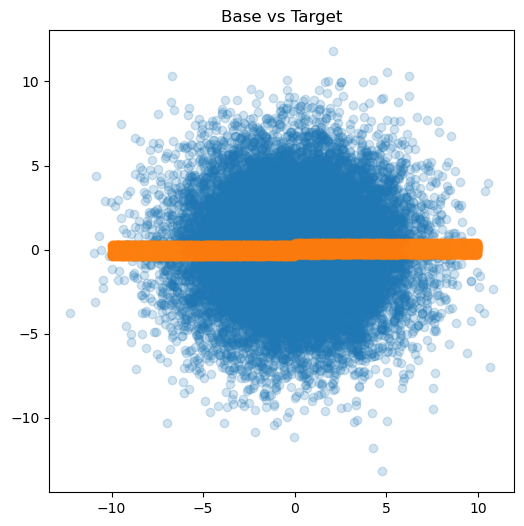

In [7]:
fig = plt.figure(figsize=(6,6,))
plt.scatter(base_samples[:,0], base_samples[:,1],  label = 'base', alpha = 0.2);
plt.scatter(target_samples[:,0], target_samples[:,1], alpha = 0.2);
plt.title("Bimodal Target")
plt.title("Base vs Target")
plt.show()

## Define Multivariate Interpolants

In [8]:
# ============================================================================
# MULTIVARIATE INTERPOLANT CONFIGURATION
# ============================================================================

# Matrix coefficients are hyperparameters (not trained)
matrix_config = {
    'matrix_type': 'diagonal',
    'exponent_p': [1.0, 1000.0],  # Exponents for A(t) = M_A * 1-t^p
    'exponent_q': [1.0, 1000.0],  # Exponents for B(t) = M_B * t^q
}

# Create the multivariate interpolant
interpolant = stochastic_interpolant.Interpolant(
    path='multivariate',
    gamma_type=None,  # No noise for deterministic interpolation
    data_type='vector',
    data_dim=2,
    matrix_config=matrix_config
)

# Display configuration
print("="*70)
print("MULTIVARIATE INTERPOLANT CONFIGURATION")
print("="*70)
print(f"Matrix type: {matrix_config['matrix_type']}")
print(f"Exponent p (for A(t)): {matrix_config['exponent_p']}")
print(f"Exponent q (for B(t)): {matrix_config['exponent_q']}")
print("="*70)
print("Note: Matrix coefficients are fixed hyperparameters (not trained)")
print("="*70)

MULTIVARIATE INTERPOLANT CONFIGURATION
Matrix type: diagonal
Exponent p (for A(t)): [1.0, 1000.0]
Exponent q (for B(t)): [1.0, 1000.0]
Note: Matrix coefficients are fixed hyperparameters (not trained)


In [9]:
path = 'one-sided-trig'

# Create interpolant without diagonal scaling for rectangular target
interpolant_aux = stochastic_interpolant.Interpolant(
    path=path, 
    gamma_type=None,
)

TESTING MULTIVARIATE INTERPOLANT

Interpolant configuration:
  Path type: multivariate
  Matrix type: diagonal
  Exponent p: [1.0, 1000.0]
  Exponent q: [1.0, 1000.0]

BOUNDARY CONDITIONS TEST
  t=0: max|x_t - x_0| = 0.000000 (should be ~0)
  t=1: max|x_t - x_1| = 0.000000 (should be ~0)
  t=0.5 sample: [-0.18980554 -0.10821664]

INTERPOLATION PATH VISUALIZATION


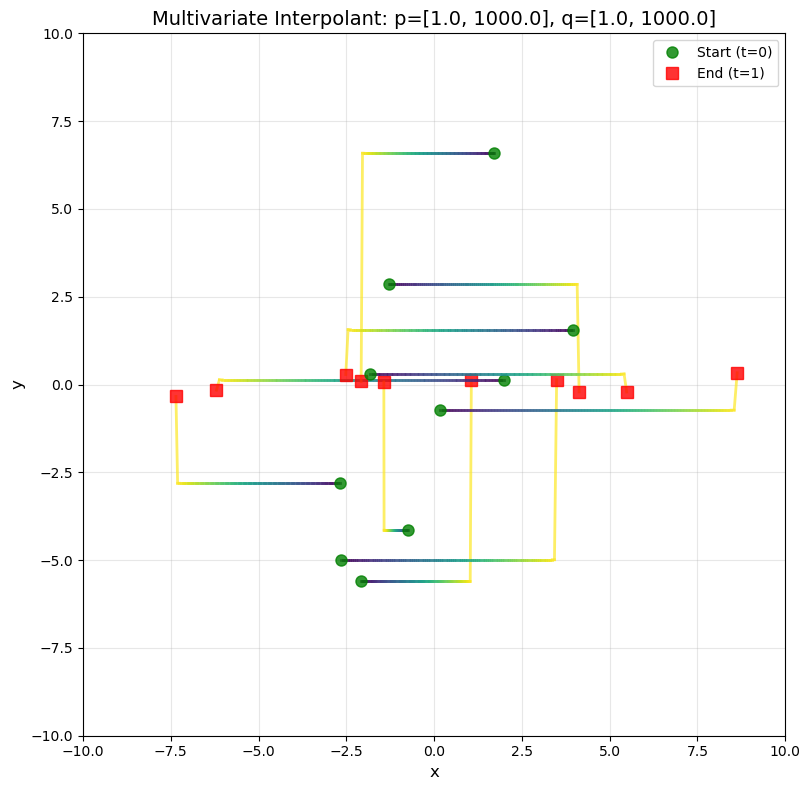


Key Observations:
1. Boundary conditions satisfied: x(0)=x_0, x(1)=x_1
2. Matrix coefficients: A(t) = diag((1-t)^p), B(t) = diag(t^q)
3. p=[1.0, 1000.0], q=[1.0, 1000.0]
4. Different exponents control interpolation speed per dimension


In [10]:
# ============================================================================
# TEST: Multivariate (Matrix-Coefficient) Interpolant
# ============================================================================

print("="*70)
print("TESTING MULTIVARIATE INTERPOLANT")
print("="*70)

# Display the interpolant configuration (using the matrix_config variable)
print(f"\nInterpolant configuration:")
print(f"  Path type: multivariate")
print(f"  Matrix type: {matrix_config['matrix_type']}")
print(f"  Exponent p: {matrix_config['exponent_p']}")
print(f"  Exponent q: {matrix_config['exponent_q']}")

# Test boundary conditions
print("\n" + "="*70)
print("BOUNDARY CONDITIONS TEST")
print("="*70)

x0_test = torch.randn(4, 2).to(device)
x1_test = torch.randn(4, 2).to(device)
t0 = torch.tensor([0.0]).to(device)
t1 = torch.tensor([1.0]).to(device)
t_mid = torch.tensor([0.5]).to(device)

xt0 = interpolant.calc_xt(t0, x0_test, x1_test)
xt1 = interpolant.calc_xt(t1, x0_test, x1_test)
xt_mid = interpolant.calc_xt(t_mid, x0_test, x1_test)

err0 = torch.max(torch.abs(xt0 - x0_test)).item()
err1 = torch.max(torch.abs(xt1 - x1_test)).item()

print(f"  t=0: max|x_t - x_0| = {err0:.6f} (should be ~0)")
print(f"  t=1: max|x_t - x_1| = {err1:.6f} (should be ~0)")
print(f"  t=0.5 sample: {xt_mid[0].cpu().numpy()}")

# Visualize interpolation paths
print("\n" + "="*70)
print("INTERPOLATION PATH VISUALIZATION")
print("="*70)

# Generate sample trajectories
n_viz = 10
x0_viz = base(n_viz).to(device)
x1_viz = target_rect(n_viz).to(device)
t_grid = torch.linspace(0, 1, 100, device=device)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot trajectories
for i in range(n_viz):
    trajectory = []
    for t in t_grid:
        xt = interpolant.calc_xt(t.unsqueeze(0), x0_viz[i:i+1], x1_viz[i:i+1])
        trajectory.append(grab(xt[0]))
    trajectory = np.array(trajectory)
    
    # Use gradient color to show time progression
    colors = plt.cm.viridis(np.linspace(0, 1, len(trajectory)-1))
    for j in range(len(trajectory)-1):
        ax.plot(trajectory[j:j+2, 0], trajectory[j:j+2, 1], 
                '-', color=colors[j], alpha=0.7, linewidth=2)
    
    # Mark start and end points
    ax.plot(trajectory[0, 0], trajectory[0, 1], 'o', color='green', 
            markersize=8, alpha=0.8, label='Start (t=0)' if i == 0 else '')
    ax.plot(trajectory[-1, 0], trajectory[-1, 1], 's', color='red', 
            markersize=8, alpha=0.8, label='End (t=1)' if i == 0 else '')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title(f'Multivariate Interpolant: p={matrix_config["exponent_p"]}, q={matrix_config["exponent_q"]}', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim([-10, 10])
ax.set_ylim([-10, 10])
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Key Observations:")
print("="*70)
print(f"1. Boundary conditions satisfied: x(0)=x_0, x(1)=x_1")
print(f"2. Matrix coefficients: A(t) = diag((1-t)^p), B(t) = diag(t^q)")
print(f"3. p={matrix_config['exponent_p']}, q={matrix_config['exponent_q']}")
print(f"4. Different exponents control interpolation speed per dimension")
print("="*70)

In [11]:
class MixedInterpolant(torch.nn.Module):
    """
    Configurable interpolant selector that can choose between base and auxiliary interpolants.

    Parameters:
    -----------
    interpolant_base : torch.nn.Module
        The primary interpolant (e.g., multivariate with matrix coefficients)
    interpolant_aux : torch.nn.Module
        The auxiliary (simple) interpolant, typically linear or one-sided-trig
    mode : str
        Selection mode: 'base', 'aux', or 'mixed'
        - 'base': Always use interpolant_base
        - 'aux': Always use interpolant_aux
        - 'mixed': Transition from aux to base over mixed_steps
    mixed_steps : int
        Number of steps for mixed transition (only used if mode='mixed')
    """
    def __init__(self, interpolant_base, interpolant_aux, mode='aux', mixed_steps=1000):
        super().__init__()
        self.interpolant_base = interpolant_base
        self.interpolant_aux = interpolant_aux
        self.mode = mode
        self.mixed_steps = mixed_steps
        self.current_step = 0

        # Validate mode
        if mode not in ['base', 'aux', 'mixed']:
            raise ValueError(f"Invalid mode: {mode}. Must be 'base', 'aux', or 'mixed'")
            
        # Check if base interpolant has a flow_model (for compatibility)
        self.has_flow_model = hasattr(interpolant_base, 'flow_model')
        
        # Create dummy flow_model if base doesn't have one (for multivariate interpolant)
        if not self.has_flow_model:
            # Create a dummy module with no parameters for API compatibility
            self.flow_model = torch.nn.Module()
        else:
            self.flow_model = interpolant_base.flow_model

    def __getattr__(self, name):
        """Forward all unknown attributes to the active interpolant."""
        # Avoid infinite recursion for module attributes
        if name in ['interpolant_base','interpolant_aux', 'mode', 'mixed_steps', 'current_step', 'has_flow_model', 'flow_model']:
            return super().__getattr__(name)

        # For calc_xt and dtIt, use our custom versions
        if name in ['calc_xt', 'dtIt']:
            return super().__getattr__(name)

        # Forward to the appropriate interpolant based on mode
        if self.mode == 'base':
            return getattr(self.interpolant_base, name)
        elif self.mode == 'aux':
            return getattr(self.interpolant_aux, name)
        else:  # mixed mode
            # For attributes like flow_model, always forward to base
            return getattr(self.interpolant_base, name)

    def set_step(self, step):
        self.current_step = step

    def set_mode(self, mode):
        """Change the interpolant selection mode."""
        if mode not in ['base', 'aux', 'mixed']:
            raise ValueError(f"Invalid mode: {mode}. Must be 'base', 'aux', or 'mixed'")
        self.mode = mode

    def get_mixed_factor(self):
        """Get blending factor for mixed mode."""
        if self.mode == 'base':
            return 1.0
        elif self.mode == 'aux':
            return 0.0
        else:  # mixed mode
            if self.current_step >= self.mixed_steps:
                return 1.0
            return 0.5 * (1 - np.cos(np.pi * self.current_step / self.mixed_steps))

    def calc_xt(self, t, x0, x1):
        """Calculate interpolated point based on current mode."""
        if self.mode == 'base':
            return self.interpolant_base.calc_xt(t, x0, x1)
        elif self.mode == 'aux':
            return self.interpolant_aux.calc_xt(t, x0, x1)
        else:  # mixed mode
            xt_complex = self.interpolant_base.calc_xt(t, x0, x1)
            xt_simple = self.interpolant_aux.calc_xt(t, x0, x1)
            alpha = self.get_mixed_factor()
            return alpha * xt_complex + (1 - alpha) * xt_simple

    def dtIt(self, t, x0, x1):
        """Calculate time derivative based on current mode."""
        if self.mode == 'base':
            return self.interpolant_base.dtIt(t, x0, x1)
        elif self.mode == 'aux':
            return self.interpolant_aux.dtIt(t, x0, x1)
        else:  # mixed mode
            dtIt_complex = self.interpolant_base.dtIt(t, x0, x1)
            dtIt_simple = self.interpolant_aux.dtIt(t, x0, x1)
            alpha = self.get_mixed_factor()
            return alpha * dtIt_complex + (1 - alpha) * dtIt_simple

    def get_active_interpolant_name(self):
        """Get descriptive name of the currently active interpolant configuration."""
        if self.mode == 'base':
            return "multivariate"
        elif self.mode == 'aux':
            return "one-sided-trig"
        else:  # mixed
            factor = self.get_mixed_factor()
            if factor == 0.0:
                return "one-sided-trig"
            elif factor == 1.0:
                return "multivariate"
            else:
                return f"mixed_{factor:.2f}"

In [12]:
# ============================================================================
# INTERPOLANT CONFIGURATION
# ============================================================================

# Choose which interpolant to use
INTERPOLANT_MODE = 'base'  # Options: 'base', 'aux', 'mixed'
# 'base' = multivariate interpolant (with matrix coefficients)
# 'aux' = one-sided-trig (simple baseline)
# 'mixed' = transition from aux to base over N_mixed steps

N_mixed = 50
N_main = 10
N_finetune = 10

# Create the configurable interpolant
mixed_interpolant = MixedInterpolant(
    interpolant_base=interpolant,      # multivariate interpolant
    interpolant_aux=interpolant_aux,   # one-sided-trig
    mode=INTERPOLANT_MODE,
    mixed_steps=N_mixed
)

print(f"Created MixedInterpolant with mode: {INTERPOLANT_MODE}")
print(f"Base interpolant: multivariate (matrix coefficients)")
print(f"Auxiliary interpolant: one-sided-trig")
print(f"Active interpolant: {mixed_interpolant.get_active_interpolant_name()}")

Created MixedInterpolant with mode: base
Base interpolant: multivariate (matrix coefficients)
Auxiliary interpolant: one-sided-trig
Active interpolant: multivariate


#### Initialize optimizer, scheduler, etc.

In [13]:
# ============================================================================
# KINK ANALYSIS & SAMPLING STRATEGY
# ============================================================================
# For polynomial interpolants with A(t) = (1 - t^p) and B(t) = t^q the trajectory
# bends whenever the relative contribution of x0 and x1 or their velocities
# change abruptly. The helper below reports the stationary kink locations under
# the simplifying assumption |x0|≈|x1|.
# ============================================================================

print("="*70)
print("KINK ANALYSIS FOR CURRENT CONFIGURATION")
print("="*70)

kink_summary = _compute_static_kink_summary(matrix_config)
alpha_param, beta_param = _get_beta_parameters_from_matrix_config(matrix_config)
kink_delta = matrix_config.get('kink_delta', 0.05) if isinstance(matrix_config, dict) else 0.05

print(f"
Matrix config: p={matrix_config.get('exponent_p')}, q={matrix_config.get('exponent_q')}")
print(f"Beta near t=1: α={alpha_param:.2f} | Beta near t=0: β={beta_param:.2f}")
print(f"Kink band half-width (δ): {kink_delta:.3f}")

if kink_summary:
    print(f"
Detected {len(kink_summary)} kink landmark(s):")
    for idx, (loc, weight) in enumerate(kink_summary, 1):
        print(f"  {idx}. t ≈ {loc:.4f} (relative weight {weight:.2f})")
    print("
Sampling components:")
    print("  • Beta(α,1) for late-time spikes")
    print("  • Beta(1,β) for early-time spikes")
    print("  • Uniform baseline over [0,1]")
    print("  • Local uniform bands of width 2δ around kink landmarks")
else:
    print("
No interior kink landmarks detected (nearly linear schedule).")
    print("Sampling falls back to Beta/Uniform mixture without kink bands.")

print("="*70)



KINK ANALYSIS FOR CURRENT CONFIGURATION

Matrix config: p=[1.0, 1000.0], q=[1.0, 1000.0]

Detected 1 kink region(s):
  1. t ≈ 0.999 (importance: 999.00)

Sampling parameters:
  Beta(α, 1) with α=1000.00 → concentrates near t=1
  Beta(1, β) with β=1000.00 → concentrates near t=0

Using 'enhanced_beta_mixture' strategy for better kink coverage.
This will sample ~35% from each Beta component + ~30% uniform.


In [14]:
base_lr_v      = 1e-3
base_lr_flow   = 5e-4  # learning rate for future trainable matrix coefficients
hidden_sizes = [128, 256, 256, 128]  # UNet hidden dimensions
in_size      = (ndim+1)
out_size     = (ndim)
inner_act    = 'gelu'
final_act    = 'none'
print_model  = True

# ============================================================================
# VELOCITY NETWORK: Lightweight UNet (MAC-inspired)
# ============================================================================
# Benefits for anisotropic checkerboard:
# - Hierarchical feature extraction handles different x/y scales well
# - Encoder-decoder structure provides better spatial awareness
# - Similar parameter count to ResNet (~499K vs ~530K) but better expressiveness
# ============================================================================

v = make_lightweight_unet_velocity_2d(
    hidden_dims=hidden_sizes,
    time_emb_dim=128,
    dropout=0.0,
    activation='gelu',
    wrapped=True  # Automatically wraps to match stochastic interpolants API
).to(device)

# Alternative: Use original ResNet (uncomment to switch back)
# v = itf.fabrics_extra.make_resnet(
#     hidden_sizes=[256, 256, 256, 256],
#     in_size=in_size,
#     out_size=out_size,
#     inner_act='gelu',
#     use_layernorm=True,
#     dropout=0.0
# )

eps          = torch.tensor(0)
N_epoch      = 250
bs           = 1000    # Increased batch size for better GPU utilization
n_inner      = 500    # inner minimization steps for v
n_outer      = 1      # Set to 1 for now (matrix coefficients are hyperparameters currently)

# Optimizer for velocity network
opt_v = torch.optim.AdamW(
      v.parameters(),
      lr=base_lr_v,
      betas=(0.9, 0.999),  # Standard Adam betas
      weight_decay=1e-4
  )
# Cosine annealing scheduler (matching script - NO warmup for better performance)
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

sched_v = CosineAnnealingWarmRestarts(
    opt_v,
    T_0=50*n_inner,      # Restart every 50 epochs
    T_mult=2,            # Double period after each restart
    eta_min=1e-6         # Minimum LR
)

# Keep flow optimizer for future when matrix coefficients become trainable
# Currently this won't have any parameters to optimize
if hasattr(mixed_interpolant, 'flow_model'):
    flow_params = list(mixed_interpolant.flow_model.parameters())
    if flow_params:  # Only create optimizer if there are parameters
        opt_flow = torch.optim.AdamW(flow_params, lr=base_lr_flow, betas=(0.5,0.9), weight_decay=1e-4)
        sched_flow = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer=opt_flow,
            T_0=20*n_outer,
            T_mult=1,
            eta_min=1e-5
        )
    else:
        # Create dummy optimizers for compatibility
        opt_flow = None
        sched_flow = None
        print("Note: No trainable flow parameters currently (matrix coefficients are hyperparameters)")
else:
    opt_flow = None
    sched_flow = None
    print("Note: Multivariate interpolant has no flow_model (matrix coefficients are hyperparameters)")

plot_bs      = 50000  # number of samples to use when plotting
metrics_freq = 50    # how often to log metrics, e.g. if logp is not super cheap don't do it everytime
plot_freq    = 500   # how often to plot
n_save       = 10    # how often to checkpoint SDE integrator
loss_fac     = 4.0   # ratio of learning rates for w to v
n_step       = 100   # number of steps taken by the SDE in [0,1]

target_kwargs = {'w': 10.0, 'h': 0.1, 'layers_x':2, 'layers_y':4, 'scale':1.0}

if print_model:
    print("="*70)
    print("VELOCITY NETWORK: Lightweight UNet")
    print("="*70)
    print(f"Architecture: Encoder-Decoder with skip connections")
    print(f"Hidden dimensions: {hidden_sizes}")
    print(f"Time embedding: 128D positional encoding")
    print(f"Total parameters: {sum(p.numel() for p in v.parameters()):,}")
    print("="*70)
    print("\nModel structure:")
    print(v)


Note: No trainable flow parameters currently (matrix coefficients are hyperparameters)
VELOCITY NETWORK: Lightweight UNet
Architecture: Encoder-Decoder with skip connections
Hidden dimensions: [128, 256, 256, 128]
Time embedding: 128D positional encoding
Total parameters: 1,981,702

Model structure:
InputWrapper(
  (v): LightweightUNetVelocity2D(
    (time_embed): Sequential(
      (0): PositionalEmbedding()
      (1): Linear(in_features=128, out_features=256, bias=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=256, out_features=256, bias=True)
    )
    (encoder_layers): ModuleList(
      (0): ResBlock(
        (norm1): GroupNorm()
        (norm2): GroupNorm()
        (fc1): Linear(in_features=2, out_features=128, bias=True)
        (fc2): Linear(in_features=128, out_features=128, bias=True)
        (time_emb_proj): Linear(in_features=256, out_features=256, bias=True)
        (skip): Linear(in_features=2, out_features=128, bias=True)
        (dropout): Identit

In [15]:
data_dict = {
    'v_losses': [],
    'flow_losses': [],  # Changed from T_losses
    'v_grads': [],
    'flow_grads': [],   # Changed from T_grads
    'times': [],
    'logps_pflow': [],
    'v_squared_norm': [],  # Add E[|v|^2] tracking
    'partial_t_v_squared_norm': [],  # Add E[|∂_t v_t|^2] tracking
}

counter = 1

In [16]:
loss_fn_v = stochastic_interpolant.make_loss(method='shared', interpolant = mixed_interpolant, loss_type='one-sided-v')
loss_fn_v_samplewise = stochastic_interpolant.make_batch_loss(
    stochastic_interpolant.losses['one-sided-v'], method='shared'
)


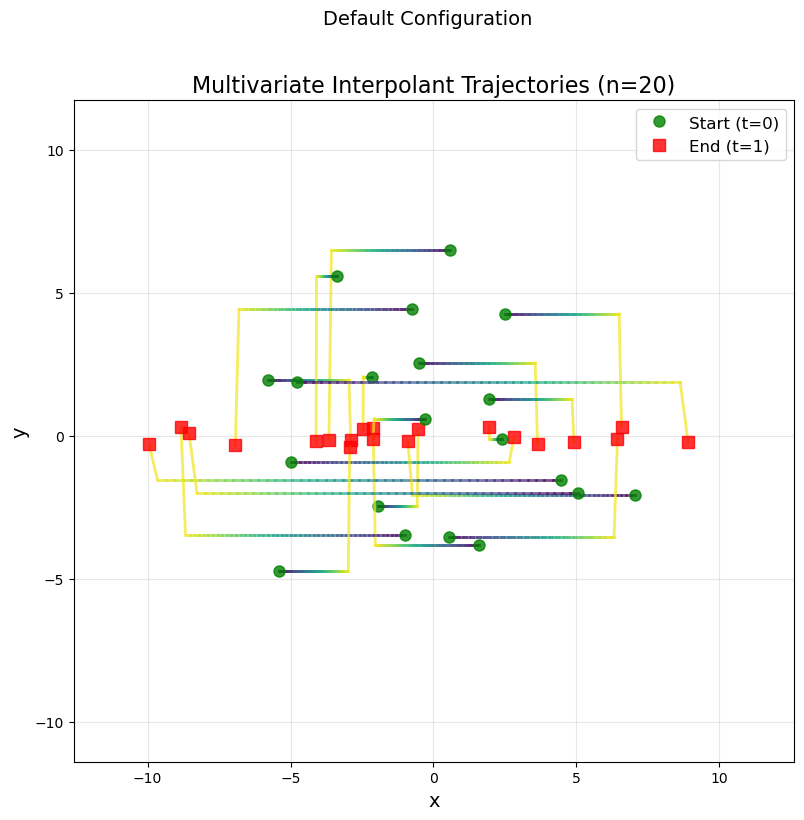

In [17]:
# Global storage for fixed trajectory endpoints for visualization
FIXED_VIZ_TRAJECTORY_POINTS = None

def get_fixed_viz_trajectory_points(base_fn, target_fn, n_trajectories=20, seed=42):
    """
    Generate or retrieve fixed start and end points for trajectory visualization.
    These points remain constant across all epochs for consistent visualization.
    """
    global FIXED_VIZ_TRAJECTORY_POINTS
    
    if FIXED_VIZ_TRAJECTORY_POINTS is None:
        # Set seed for reproducibility
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Generate diverse starting and ending points
        x0_points = base_fn(n_trajectories).to(device)
        x1_points = target_fn(n_trajectories).to(device)
        
        FIXED_VIZ_TRAJECTORY_POINTS = {
            'x0': x0_points.detach().clone(),
            'x1': x1_points.detach().clone(),
            'seed': seed,
            'n_trajectories': n_trajectories
        }
        
        # Reset random state
        torch.manual_seed(torch.initial_seed() if torch.initial_seed() is not None else int(time.time()))
        
    return FIXED_VIZ_TRAJECTORY_POINTS['x0'], FIXED_VIZ_TRAJECTORY_POINTS['x1']


def visualize_multivariate_interpolant(interpolant, base, target, n_samples=5000, n_time_points=10, 
                                      n_viz_trajectories=20, trajectory_seed=42,
                                      save_path=None, epoch=None):
    """
    Visualize the multivariate interpolant paths.
    
    Parameters:
    -----------
    save_path : str, optional
        Directory to save the plots
    epoch : int, optional
        Epoch number for file naming
    """
    
    # Handle both direct interpolant and MixedInterpolant wrapper
    if hasattr(interpolant, 'interpolant_base'):
        # It's a MixedInterpolant, get the base (multivariate) interpolant
        multivar_interpolant = interpolant.interpolant_base
    else:
        # Direct interpolant
        multivar_interpolant = interpolant
    
    # Determine appropriate axis limits based on data
    with torch.no_grad():
        sample_x0 = base(1000).to(device)
        sample_x1 = target(1000).to(device)
        
        # Calculate data ranges
        x_min = min(sample_x0[:, 0].min().item(), sample_x1[:, 0].min().item())
        x_max = max(sample_x0[:, 0].max().item(), sample_x1[:, 0].max().item())
        y_min = min(sample_x0[:, 1].min().item(), sample_x1[:, 1].min().item())
        y_max = max(sample_x0[:, 1].max().item(), sample_x1[:, 1].max().item())
        
        # Add some padding
        x_range = x_max - x_min
        y_range = y_max - y_min
        x_lim = (x_min - 0.1 * x_range, x_max + 0.1 * x_range)
        y_lim = (y_min - 0.1 * y_range, y_max + 0.1 * y_range)
    
    # Create figure with single subplot for trajectories
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Get fixed trajectory endpoints
    x0_viz, x1_viz = get_fixed_viz_trajectory_points(base, target, n_viz_trajectories, trajectory_seed)
    
    # Plot trajectories
    with torch.no_grad():
        t_dense = torch.linspace(0, 1, 50, device=device)
        
        # Create a colormap for time
        colors = plt.cm.viridis(np.linspace(0, 1, len(t_dense)))
        
        for i in range(n_viz_trajectories):
            trajectory = []
            
            for t in t_dense:
                t_tensor = t.unsqueeze(0)
                
                # Multivariate interpolation
                x_mv = multivar_interpolant.calc_xt(t_tensor, x0_viz[i:i+1], x1_viz[i:i+1])
                if isinstance(x_mv, tuple):
                    x_mv = x_mv[0]
                trajectory.append(grab(x_mv[0]))
            
            trajectory = np.array(trajectory)
            
            # Plot trajectory with gradient color
            for j in range(len(trajectory) - 1):
                ax.plot(trajectory[j:j+2, 0], trajectory[j:j+2, 1], 
                       '-', color=colors[j], alpha=0.7, linewidth=2)
            
            # Mark start and end points
            ax.plot(trajectory[0, 0], trajectory[0, 1], 'o', 
                   color='green', markersize=8, alpha=0.8, 
                   label='Start (t=0)' if i == 0 else '')
            ax.plot(trajectory[-1, 0], trajectory[-1, 1], 's', 
                   color='red', markersize=8, alpha=0.8,
                   label='End (t=1)' if i == 0 else '')
    
    ax.set_xlabel('x', fontsize=14)
    ax.set_ylabel('y', fontsize=14)
    ax.set_title(f'Multivariate Interpolant Trajectories (n={n_viz_trajectories})', fontsize=16)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    
    # Set aspect ratio to match the data
    ax.set_aspect('equal', adjustable='box')
    
    # Add overall title with epoch information and matrix config
    if hasattr(multivar_interpolant, 'matrix_config'):
        config_str = f"Matrix Config: p={multivar_interpolant.matrix_config['exponent_p']}, q={multivar_interpolant.matrix_config['exponent_q']}"
    else:
        config_str = "Default Configuration"
    
    if epoch is not None:
        title_str = f'Epoch {epoch} | {config_str}'
    else:
        title_str = config_str
    
    fig.suptitle(title_str, fontsize=14, y=1.02)
    
    plt.tight_layout()
    
    # Save the figure if save_path is provided
    if save_path is not None:
        import os
        os.makedirs(save_path, exist_ok=True)
        
        if epoch is not None:
            filename = f"{save_path}/multivariate_trajectories_epoch_{epoch:04d}.png"
        else:
            filename = f"{save_path}/multivariate_trajectories.png"
        plt.savefig(filename, dpi=100, bbox_inches='tight')
        print(f"Saved multivariate interpolant plot to {filename}")
    
    plt.show()


# Visualize multivariate interpolant
visualize_multivariate_interpolant(mixed_interpolant, base, target_rect, 
                                  n_samples=5000, n_viz_trajectories=20)

Experiment will be saved to: results_multivariate_rect/exp_20251014_183956_w10.0h0.10_bvar3.0_interp_base_p1.0_1000.0_q1.0_1000.0_1e-03_500i_250ep_1000bs
Base distribution variance: 3.0
Interpolant mode: base
Matrix config: p=[1.0, 1000.0], q=[1.0, 1000.0]
Configuration saved to: results_multivariate_rect/exp_20251014_183956_w10.0h0.10_bvar3.0_interp_base_p1.0_1000.0_q1.0_1000.0_1e-03_500i_250ep_1000bs/experiment_config.json

Starting training for 250 epochs...
Base variance: 3.0, Target: rect, Interpolant: base
Epoch 1/250 [multivariate]: v_loss=-3.5715, flow_loss=0.0000, v_grad=32.3810, flow_grad=0.0000, E[|v|²]=13.7228
Epoch 2/250 [multivariate]: v_loss=-9.3009, flow_loss=0.0000, v_grad=68.4718, flow_grad=0.0000, E[|v|²]=11.1508
Epoch 3/250 [multivariate]: v_loss=-6.0437, flow_loss=0.0000, v_grad=21.0706, flow_grad=0.0000, E[|v|²]=14.6964
Epoch 4/250 [multivariate]: v_loss=-6.8968, flow_loss=0.0000, v_grad=56.9771, flow_grad=0.0000, E[|v|²]=18.2930
Epoch 5/250 [multivariate]: v_loss

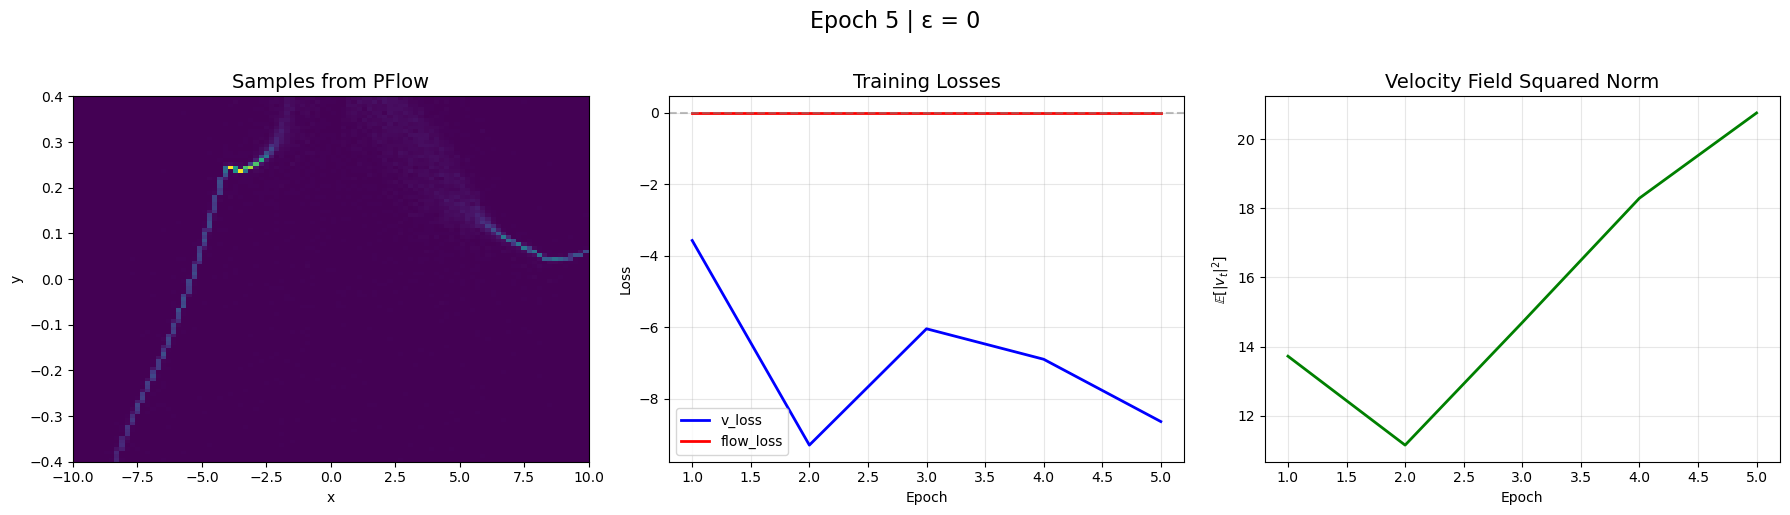

  [make_plots] Plot display complete.
Epoch 6/250 [multivariate]: v_loss=-10.7435, flow_loss=0.0000, v_grad=128.8258, flow_grad=0.0000, E[|v|²]=20.0764
Epoch 7/250 [multivariate]: v_loss=-4.5286, flow_loss=0.0000, v_grad=25.6988, flow_grad=0.0000, E[|v|²]=12.9739
Epoch 8/250 [multivariate]: v_loss=-4.6282, flow_loss=0.0000, v_grad=129.1046, flow_grad=0.0000, E[|v|²]=7.4519
Epoch 9/250 [multivariate]: v_loss=-100.9365, flow_loss=0.0000, v_grad=912.7118, flow_grad=0.0000, E[|v|²]=98.7071
Epoch 10/250 [multivariate]: v_loss=-6.2577, flow_loss=0.0000, v_grad=224.4302, flow_grad=0.0000, E[|v|²]=13.4503
  [make_plots] Computing likelihoods with bs=50000...
  [make_plots] Likelihood computation complete. Creating plots...
  [make_plots] Saved plot to results_multivariate_rect/exp_20251014_183956_w10.0h0.10_bvar3.0_interp_base_p1.0_1000.0_q1.0_1000.0_1e-03_500i_250ep_1000bs/plots_epoch_0010.png


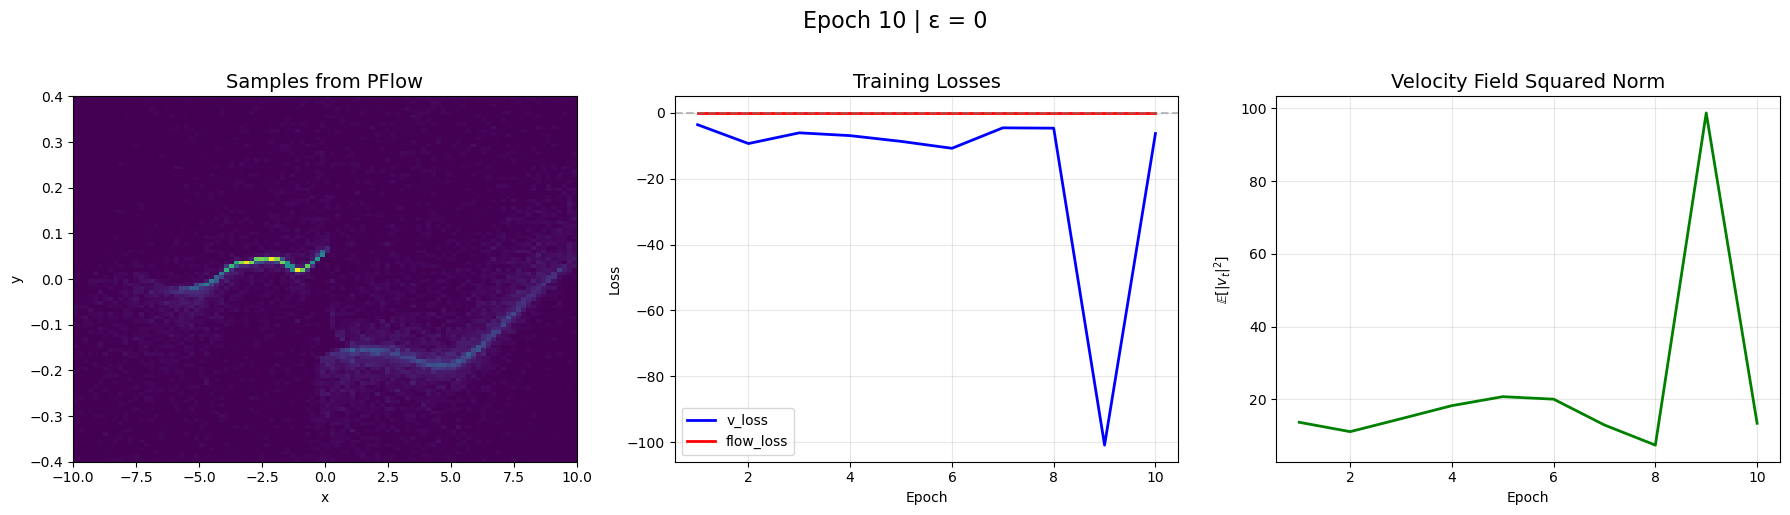

  [make_plots] Plot display complete.
Epoch 11/250 [multivariate]: v_loss=-7.5078, flow_loss=0.0000, v_grad=167.9813, flow_grad=0.0000, E[|v|²]=11.9541
Epoch 12/250 [multivariate]: v_loss=-5.1998, flow_loss=0.0000, v_grad=117.1130, flow_grad=0.0000, E[|v|²]=11.1853
Epoch 13/250 [multivariate]: v_loss=-5.0183, flow_loss=0.0000, v_grad=61.5243, flow_grad=0.0000, E[|v|²]=12.7302
Epoch 14/250 [multivariate]: v_loss=-5.3167, flow_loss=0.0000, v_grad=299.0371, flow_grad=0.0000, E[|v|²]=16.2149
Epoch 15/250 [multivariate]: v_loss=0.4384, flow_loss=0.0000, v_grad=117.6745, flow_grad=0.0000, E[|v|²]=13.4453
  [make_plots] Computing likelihoods with bs=50000...
  [make_plots] Likelihood computation complete. Creating plots...
  [make_plots] Saved plot to results_multivariate_rect/exp_20251014_183956_w10.0h0.10_bvar3.0_interp_base_p1.0_1000.0_q1.0_1000.0_1e-03_500i_250ep_1000bs/plots_epoch_0015.png


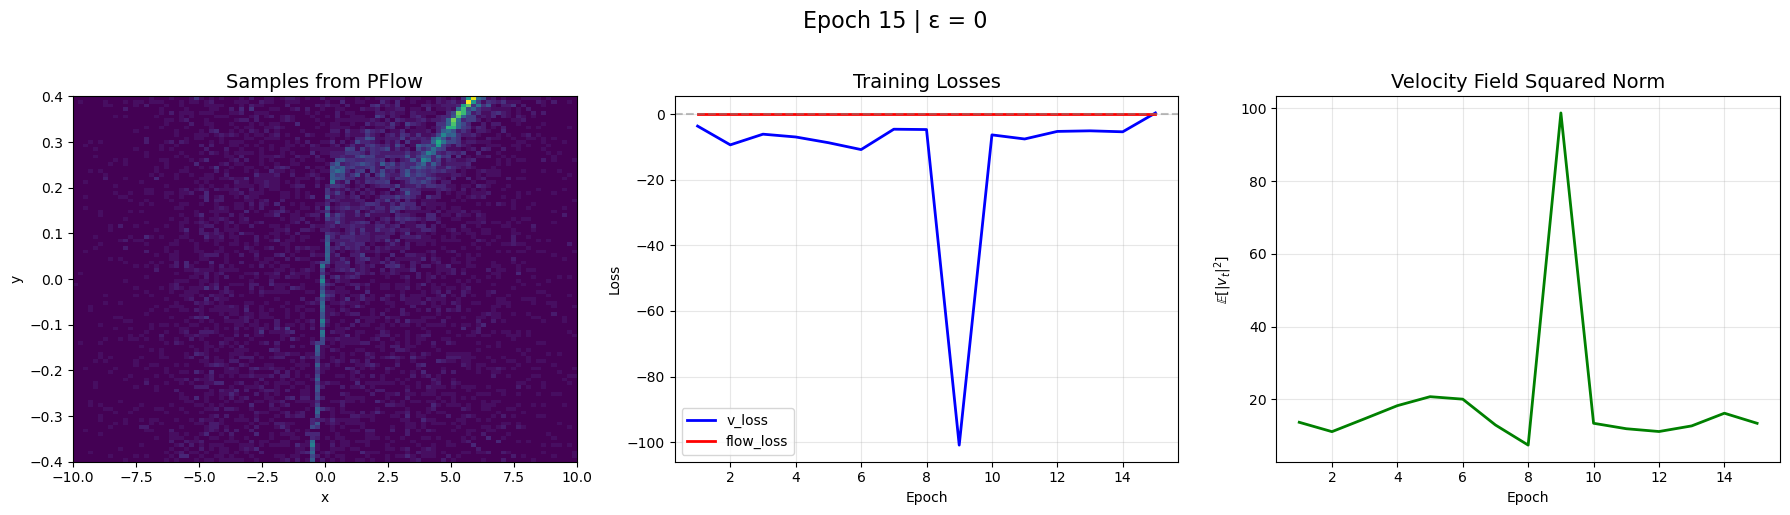

  [make_plots] Plot display complete.
Epoch 16/250 [multivariate]: v_loss=6.8775, flow_loss=0.0000, v_grad=461.4485, flow_grad=0.0000, E[|v|²]=6.1983
Epoch 17/250 [multivariate]: v_loss=-4.6721, flow_loss=0.0000, v_grad=84.8251, flow_grad=0.0000, E[|v|²]=7.7581
Epoch 18/250 [multivariate]: v_loss=6.1007, flow_loss=0.0000, v_grad=563.7185, flow_grad=0.0000, E[|v|²]=59.1299
Epoch 19/250 [multivariate]: v_loss=-1.5719, flow_loss=0.0000, v_grad=410.2340, flow_grad=0.0000, E[|v|²]=24.6199
Epoch 20/250 [multivariate]: v_loss=-20.5458, flow_loss=0.0000, v_grad=1523.4849, flow_grad=0.0000, E[|v|²]=40.0642
  [make_plots] Computing likelihoods with bs=50000...
  [make_plots] Likelihood computation complete. Creating plots...
  [make_plots] Saved plot to results_multivariate_rect/exp_20251014_183956_w10.0h0.10_bvar3.0_interp_base_p1.0_1000.0_q1.0_1000.0_1e-03_500i_250ep_1000bs/plots_epoch_0020.png


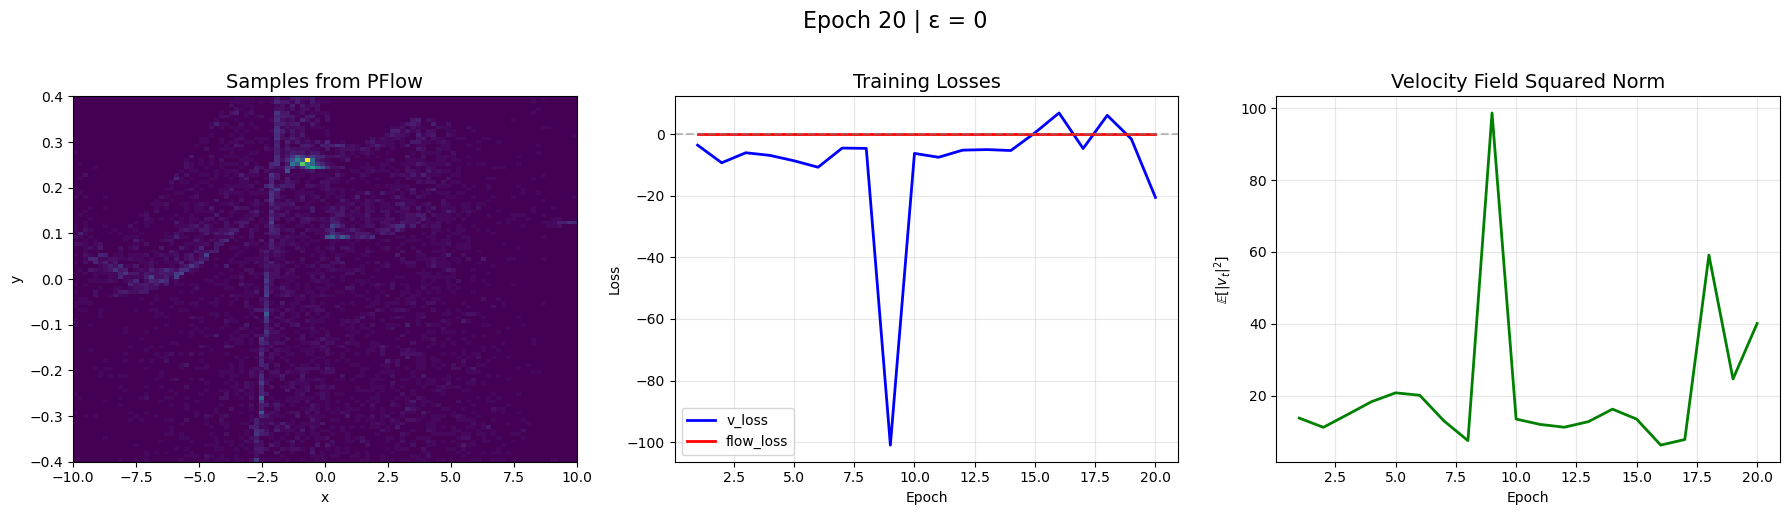

  [make_plots] Plot display complete.
Epoch 21/250 [multivariate]: v_loss=14.8234, flow_loss=0.0000, v_grad=906.6174, flow_grad=0.0000, E[|v|²]=69.0702
Epoch 22/250 [multivariate]: v_loss=-30.7130, flow_loss=0.0000, v_grad=494.6326, flow_grad=0.0000, E[|v|²]=29.0673
Epoch 23/250 [multivariate]: v_loss=-14.3183, flow_loss=0.0000, v_grad=423.4793, flow_grad=0.0000, E[|v|²]=17.9697
Epoch 24/250 [multivariate]: v_loss=-356.1147, flow_loss=0.0000, v_grad=16703.9688, flow_grad=0.0000, E[|v|²]=134.8230
Epoch 25/250 [multivariate]: v_loss=-22.5667, flow_loss=0.0000, v_grad=937.9091, flow_grad=0.0000, E[|v|²]=19.6233
  [make_plots] Computing likelihoods with bs=50000...
  [make_plots] Likelihood computation complete. Creating plots...
  [make_plots] Saved plot to results_multivariate_rect/exp_20251014_183956_w10.0h0.10_bvar3.0_interp_base_p1.0_1000.0_q1.0_1000.0_1e-03_500i_250ep_1000bs/plots_epoch_0025.png


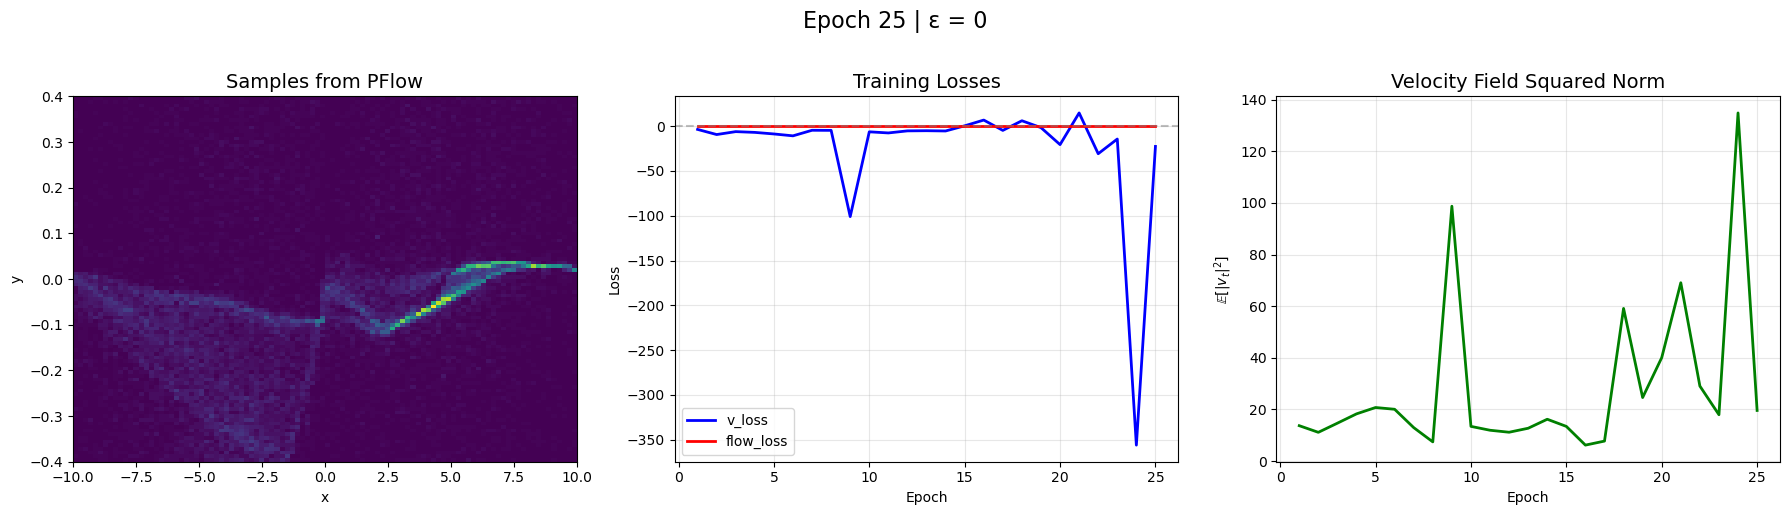

  [make_plots] Plot display complete.
Epoch 26/250 [multivariate]: v_loss=-17.6700, flow_loss=0.0000, v_grad=825.2717, flow_grad=0.0000, E[|v|²]=17.8604
Epoch 27/250 [multivariate]: v_loss=-125.2657, flow_loss=0.0000, v_grad=1808.8899, flow_grad=0.0000, E[|v|²]=106.5159
Epoch 28/250 [multivariate]: v_loss=-8.1511, flow_loss=0.0000, v_grad=2968.9985, flow_grad=0.0000, E[|v|²]=211.8365
Epoch 29/250 [multivariate]: v_loss=-9.4917, flow_loss=0.0000, v_grad=374.1862, flow_grad=0.0000, E[|v|²]=17.3340
Epoch 30/250 [multivariate]: v_loss=-10.7012, flow_loss=0.0000, v_grad=203.6026, flow_grad=0.0000, E[|v|²]=23.0574
  [make_plots] Computing likelihoods with bs=50000...
  [make_plots] Likelihood computation complete. Creating plots...
  [make_plots] Saved plot to results_multivariate_rect/exp_20251014_183956_w10.0h0.10_bvar3.0_interp_base_p1.0_1000.0_q1.0_1000.0_1e-03_500i_250ep_1000bs/plots_epoch_0030.png


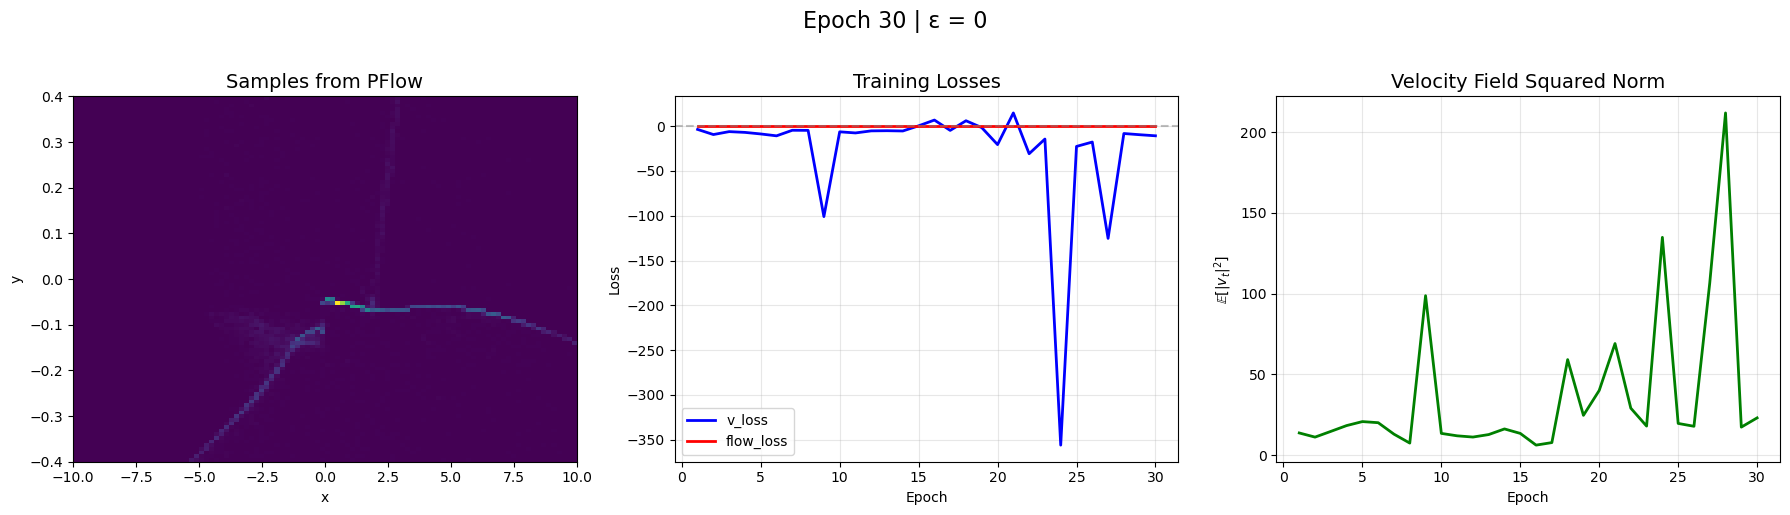

  [make_plots] Plot display complete.
Epoch 31/250 [multivariate]: v_loss=-64.2309, flow_loss=0.0000, v_grad=2432.2659, flow_grad=0.0000, E[|v|²]=132.4626
Epoch 32/250 [multivariate]: v_loss=-18.8832, flow_loss=0.0000, v_grad=1065.5129, flow_grad=0.0000, E[|v|²]=39.1064
Epoch 33/250 [multivariate]: v_loss=-0.9328, flow_loss=0.0000, v_grad=3509.8958, flow_grad=0.0000, E[|v|²]=26.3975
Epoch 34/250 [multivariate]: v_loss=-200.2145, flow_loss=0.0000, v_grad=13822.1846, flow_grad=0.0000, E[|v|²]=261.2739
Epoch 35/250 [multivariate]: v_loss=-61.9165, flow_loss=0.0000, v_grad=73984.5938, flow_grad=0.0000, E[|v|²]=2406.7609
  [make_plots] Computing likelihoods with bs=50000...
  [make_plots] Likelihood computation complete. Creating plots...
  [make_plots] Saved plot to results_multivariate_rect/exp_20251014_183956_w10.0h0.10_bvar3.0_interp_base_p1.0_1000.0_q1.0_1000.0_1e-03_500i_250ep_1000bs/plots_epoch_0035.png


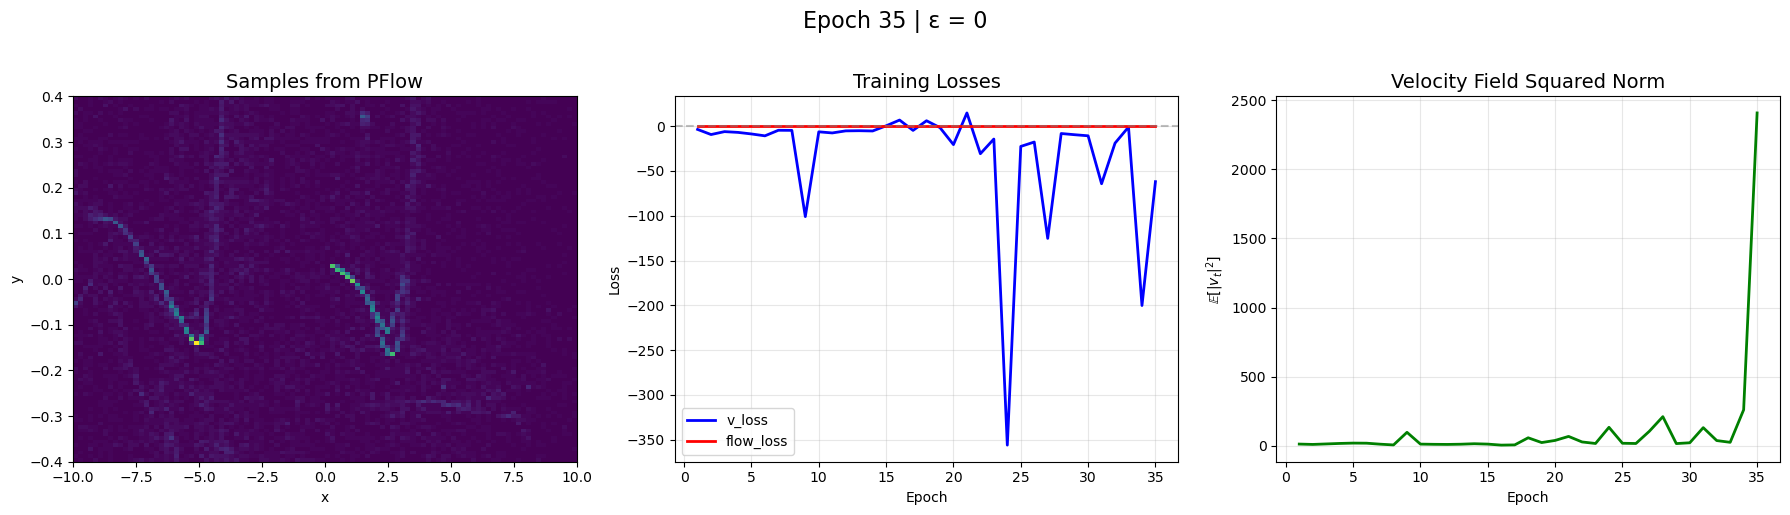

  [make_plots] Plot display complete.
Epoch 36/250 [multivariate]: v_loss=-71.1348, flow_loss=0.0000, v_grad=47047.5820, flow_grad=0.0000, E[|v|²]=1506.4000
Epoch 37/250 [multivariate]: v_loss=36.0385, flow_loss=0.0000, v_grad=7312.9551, flow_grad=0.0000, E[|v|²]=352.6707
Epoch 38/250 [multivariate]: v_loss=42.8068, flow_loss=0.0000, v_grad=6040.9707, flow_grad=0.0000, E[|v|²]=376.3457
Epoch 39/250 [multivariate]: v_loss=-145.2371, flow_loss=0.0000, v_grad=3780.7166, flow_grad=0.0000, E[|v|²]=39.3354
Epoch 40/250 [multivariate]: v_loss=49.9914, flow_loss=0.0000, v_grad=30580.3594, flow_grad=0.0000, E[|v|²]=2034.8131
  [make_plots] Computing likelihoods with bs=50000...
  [make_plots] Likelihood computation complete. Creating plots...
  [make_plots] Saved plot to results_multivariate_rect/exp_20251014_183956_w10.0h0.10_bvar3.0_interp_base_p1.0_1000.0_q1.0_1000.0_1e-03_500i_250ep_1000bs/plots_epoch_0040.png


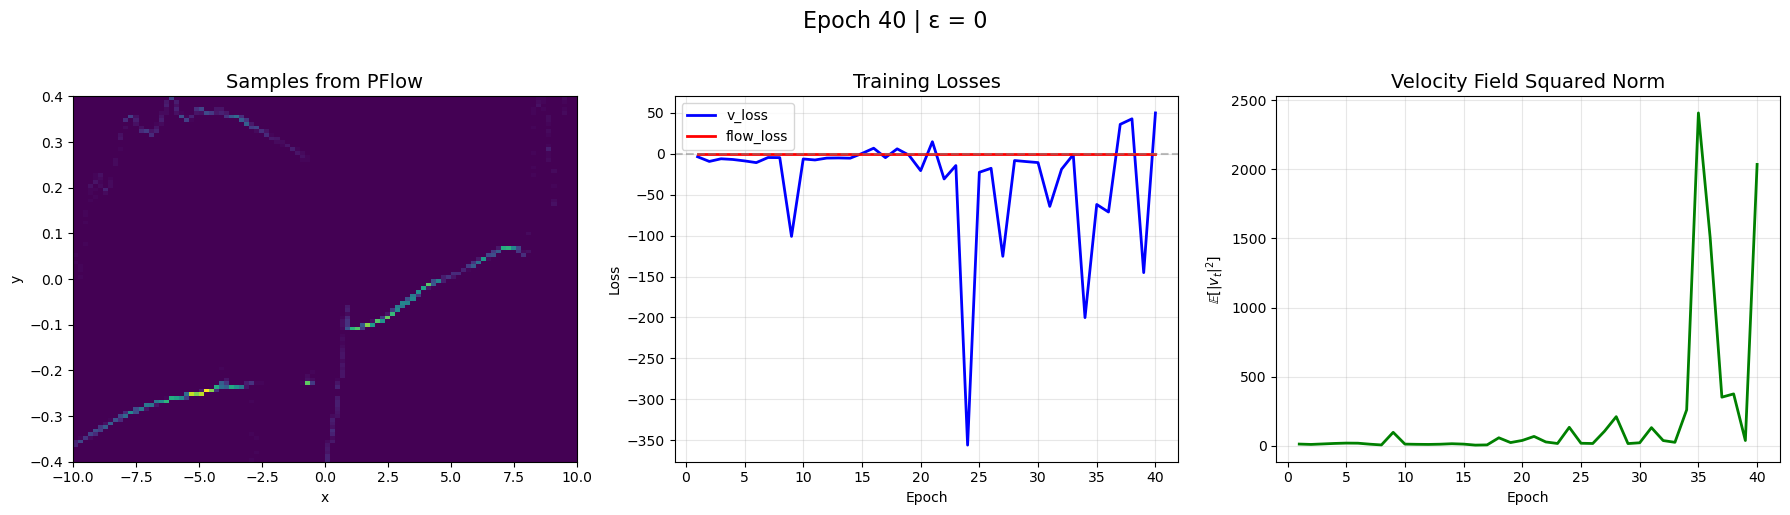

  [make_plots] Plot display complete.
Epoch 41/250 [multivariate]: v_loss=-87.9063, flow_loss=0.0000, v_grad=2414.9890, flow_grad=0.0000, E[|v|²]=246.1427
Epoch 42/250 [multivariate]: v_loss=-68.3930, flow_loss=0.0000, v_grad=55950.4883, flow_grad=0.0000, E[|v|²]=1936.3043
Epoch 43/250 [multivariate]: v_loss=-1681.1471, flow_loss=0.0000, v_grad=9484.9541, flow_grad=0.0000, E[|v|²]=1589.1960
Epoch 44/250 [multivariate]: v_loss=-5039.3818, flow_loss=0.0000, v_grad=215136.6875, flow_grad=0.0000, E[|v|²]=5133.4841
Epoch 45/250 [multivariate]: v_loss=-14.0210, flow_loss=0.0000, v_grad=11213.0645, flow_grad=0.0000, E[|v|²]=1189.2296
  [make_plots] Computing likelihoods with bs=50000...
  [make_plots] Likelihood computation complete. Creating plots...
  [make_plots] Saved plot to results_multivariate_rect/exp_20251014_183956_w10.0h0.10_bvar3.0_interp_base_p1.0_1000.0_q1.0_1000.0_1e-03_500i_250ep_1000bs/plots_epoch_0045.png


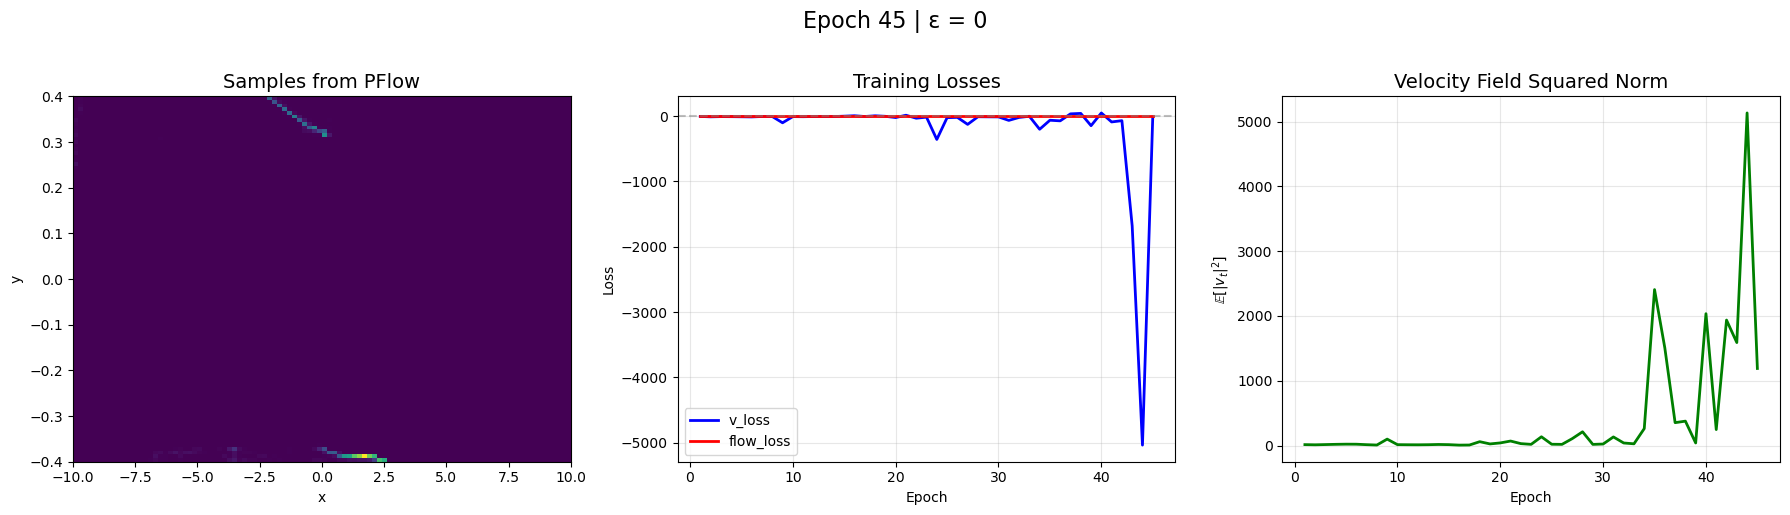

  [make_plots] Plot display complete.
Epoch 46/250 [multivariate]: v_loss=-8.6791, flow_loss=0.0000, v_grad=1987.6943, flow_grad=0.0000, E[|v|²]=1150.3517
Epoch 47/250 [multivariate]: v_loss=-10116.9258, flow_loss=0.0000, v_grad=2224476.2500, flow_grad=0.0000, E[|v|²]=2712.7547
Epoch 48/250 [multivariate]: v_loss=-269.4070, flow_loss=0.0000, v_grad=86820.7422, flow_grad=0.0000, E[|v|²]=2254.8968
Epoch 49/250 [multivariate]: v_loss=-3028.6169, flow_loss=0.0000, v_grad=476957.0938, flow_grad=0.0000, E[|v|²]=3423.1031


KeyboardInterrupt: 

In [94]:
# ============================================================================
# EXPERIMENT CONFIGURATION AND SAVING
# ============================================================================

import os
import json
from datetime import datetime

def create_experiment_path(target_type, target_kwargs, matrix_config, base_lr_v, 
                          n_inner, N_epoch, bs, base_variance, interpolant_mode):
    """Create organized experiment directory name with key parameters."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Format target parameters based on target type
    if target_type == "rect":
        target_str = f"w{target_kwargs.get('w', 1.0):.1f}h{target_kwargs.get('h', 0.1):.2f}"
    elif target_type == "rhombus":
        target_str = f"s{target_kwargs.get('s', 1.0):.1f}a{target_kwargs.get('angle_deg', 10):.0f}"
    elif target_type == "parallelogram":
        target_str = f"a{target_kwargs.get('len_a', 1):.1f}b{target_kwargs.get('len_b', 1):.1f}ang{target_kwargs.get('angle_deg', 60):.0f}"
    else:
        target_str = target_type
    
    # Format matrix config
    p_str = str(matrix_config.get('exponent_p', [1.0, 1.0])).replace('[', '').replace(']', '').replace(', ', '_')
    q_str = str(matrix_config.get('exponent_q', [1.0, 1.0])).replace('[', '').replace(']', '').replace(', ', '_')
    matrix_str = f"p{p_str}_q{q_str}"
    
    # Format base variance (e.g., bvar1.0 or bvar0.5)
    base_var_str = f"bvar{base_variance:.1f}"
    
    # Format interpolant mode
    interp_str = f"interp_{interpolant_mode}"
    
    # Create path
    path = f"results_multivariate_{target_type}/exp_{timestamp}_{target_str}_{base_var_str}_{interp_str}_{matrix_str}_{base_lr_v:.0e}_{n_inner}i_{N_epoch}ep_{bs}bs"
    
    return path

def make_json_serializable(obj):
    """Convert non-serializable objects to serializable format."""
    import torch
    import numpy as np
    
    if isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_json_serializable(v) for v in obj]
    elif isinstance(obj, torch.device):
        return str(obj)
    elif isinstance(obj, torch.dtype):
        return str(obj)
    elif torch.is_tensor(obj):
        return obj.detach().cpu().tolist()
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    else:
        return obj

def save_experiment_config(save_path, target_type, target_kwargs, matrix_config, 
                          base_lr_v, n_inner, N_epoch, bs,
                          hidden_sizes, metrics_freq, plot_freq, n_save, n_step, base_variance,
                          interpolant_mode, mixed_steps=None):
    """Save all experiment configuration to a JSON file."""
    
    # Clean target_kwargs for JSON serialization
    clean_target_kwargs = make_json_serializable(target_kwargs)
    
    config = {
        "experiment": {
            "timestamp": datetime.now().isoformat(),
            "save_path": save_path,
            "target_type": target_type,
        },
        "interpolant": {
            "mode": interpolant_mode,
            "active_type": "multivariate" if interpolant_mode == "base" else "one-sided-trig" if interpolant_mode == "aux" else "mixed",
            "mixed_steps": mixed_steps if interpolant_mode == "mixed" else None,
            "base_type": "multivariate",
            "aux_type": "one-sided-trig"
        },
        "multivariate_config": matrix_config,
        "base_distribution": {
            "type": "SimpleNormal",
            "mean": 0.0,
            "variance": base_variance,
            "dimension": 2
        },
        "target_parameters": clean_target_kwargs,
        "training": {
            "base_lr_v": base_lr_v,
            "n_inner": n_inner,
            "n_outer": n_outer,  # Currently 1 since matrix coefficients are hyperparameters
            "N_epoch": N_epoch,
            "batch_size": bs,
        },
        "network": {
            "v_hidden_sizes": hidden_sizes,
            "v_activation": inner_act,
        },
        "logging": {
            "metrics_freq": metrics_freq,
            "plot_freq": plot_freq,
            "n_save": n_save,
            "n_step": n_step,
        }
    }
    
    # Create directory if it doesn't exist
    os.makedirs(save_path, exist_ok=True)
    
    # Save config
    config_path = os.path.join(save_path, "experiment_config.json")
    with open(config_path, "w") as f:
        json.dump(config, f, indent=2)
    
    print(f"Configuration saved to: {config_path}")
    return config

def save_training_results(save_path, data_dict):
    """Save training metrics to JSON file."""
    data_path = os.path.join(save_path, "training_metrics.json")
    
    def _json_default(o):
        import numpy as np, torch
        if isinstance(o, (np.floating, np.integer)):
            return o.item()
        if isinstance(o, np.ndarray):
            return o.tolist()
        if torch.is_tensor(o):
            return o.detach().cpu().tolist()
        raise TypeError(f"Object of type {type(o).__name__} is not JSON serializable")
    
    with open(data_path, "w") as f:
        json.dump(data_dict, f, indent=2, default=_json_default)
    
    print(f"Training metrics saved to: {data_path}")

# ============================================================================
# CONFIGURE YOUR EXPERIMENT HERE
# ============================================================================

# Choose target type and parameters
target_type = "rect"  # Options: "rect", "rhombus", "parallelogram"
target_kwargs = {
    'w': 10.0,
    'h': 0.1,
    'layers_x': 2,
    'layers_y': 4,
    'scale': 1.0,
    'device': device,
    'dtype': torch.float32
}

# Select target function based on type
if target_type == "rect":
    target_fn = target_rect
elif target_type == "rhombus":
    target_fn = target_rhombus
elif target_type == "parallelogram":
    target_fn = target_parallelogram
else:
    target_fn = target  # Default checker

# Create organized save path
save_path = create_experiment_path(
    target_type=target_type,
    target_kwargs=target_kwargs,
    matrix_config=matrix_config,
    base_lr_v=base_lr_v,
    n_inner=n_inner,
    N_epoch=N_epoch,
    bs=bs,
    base_variance=base_variance,
    interpolant_mode=INTERPOLANT_MODE
)

print(f"Experiment will be saved to: {save_path}")
print(f"Base distribution variance: {base_variance}")
print(f"Interpolant mode: {INTERPOLANT_MODE}")
print(f"Matrix config: p={matrix_config['exponent_p']}, q={matrix_config['exponent_q']}")

# Save experiment configuration
experiment_config = save_experiment_config(
    save_path=save_path,
    target_type=target_type,
    target_kwargs=target_kwargs,
    matrix_config=matrix_config,
    base_lr_v=base_lr_v,
    n_inner=n_inner,
    N_epoch=N_epoch,
    bs=bs,
    hidden_sizes=hidden_sizes,
    metrics_freq=metrics_freq,
    plot_freq=plot_freq,
    n_save=n_save,
    n_step=n_step,
    base_variance=base_variance,
    interpolant_mode=INTERPOLANT_MODE,
    mixed_steps=N_mixed if INTERPOLANT_MODE == 'mixed' else None
)

# ============================================================================
# TRAINING LOOP
# ============================================================================

print(f"\nStarting training for {N_epoch} epochs...")
print(f"Base variance: {base_variance}, Target: {target_type}, Interpolant: {INTERPOLANT_MODE}")
print("="*70)

for epoch in range(N_epoch):
    # Training step with configured target
    loss_v, loss_flow, v_grad, flow_grad = train_step(
        bs=bs,
        interpolant=mixed_interpolant,
        v=v,
        opt_v=opt_v,
        opt_flow=opt_flow,
        sched_v=sched_v,
        sched_flow=sched_flow,
        n_inner=n_inner,
        n_outer=n_outer,
        reuse_batch=False,
        clip_v=float('inf'),
        clip_flow=float('inf'),
        train_v_only=False,
        mixed_step=epoch,
        base_fn=base,
        target_fn=target_fn,
        target_kwargs=target_kwargs,
        matrix_cfg=matrix_config,
        device=device
    )

    # Log metrics
    data_dict['v_losses'].append(grab(loss_v).mean())
    data_dict['flow_losses'].append(grab(loss_flow).mean())
    data_dict['v_grads'].append(grab(v_grad).mean())
    data_dict['flow_grads'].append(grab(flow_grad).mean())

    # Estimate E[|v|^2]
    v_sq_norm = estimate_v_squared_norm_grid(
        v, mixed_interpolant, base, target_fn,
        n_samples=50000, n_time_points=100, device=device
    )
    data_dict['v_squared_norm'].append(v_sq_norm)

    # Print progress
    active_interp = mixed_interpolant.get_active_interpolant_name()
    print(f"Epoch {epoch+1}/{N_epoch} [{active_interp}]: v_loss={loss_v.item():.4f}, "
          f"flow_loss={loss_flow.item():.4f}, v_grad={v_grad.item():.4f}, "
          f"flow_grad={flow_grad.item():.4f}, E[|v|²]={v_sq_norm:.4f}")

    # Save plots periodically (every 10 epochs) and at the end
    if (epoch + 1) % 5 == 0 or epoch == N_epoch - 1:
        # Create width/height for plotting based on target type
        if target_type == "rect":
            plot_width = target_kwargs.get('w', 1.0) * target_kwargs.get('layers_x', 2) * target_kwargs.get('scale', 1.0) / 2
            plot_height = target_kwargs.get('h', 0.1) * target_kwargs.get('layers_y', 4) * target_kwargs.get('scale', 1.0)
        else:
            plot_width = 1.0
            plot_height = 0.1
            
        make_plots(
            v, v, mixed_interpolant, n_save, n_step, plot_bs, counter, metrics_freq,
            torch.tensor(0), data_dict, 
            save_path=save_path, 
            epoch=epoch+1, 
            width=plot_width, 
            height=plot_height
        )
        
        # Visualize multivariate interpolant trajectories
        # visualize_multivariate_interpolant(
        #     mixed_interpolant, base, target_fn, n_samples=5000,
        #     save_path=save_path,
        #     epoch=epoch+1
        # )

# ============================================================================
# SAVE FINAL RESULTS
# ============================================================================

print("\n" + "="*70)
print("Training complete! Saving results...")

# Save training metrics
save_training_results(save_path, data_dict)

# Save model checkpoints
checkpoint_path = os.path.join(save_path, "model_checkpoint.pt")
torch.save({
    'epoch': N_epoch,
    'v_state_dict': v.state_dict(),
    'data_dict': data_dict,
    'base_variance': base_variance,
    'interpolant_mode': INTERPOLANT_MODE,
    'matrix_config': matrix_config,
    'mixed_steps': N_mixed if INTERPOLANT_MODE == 'mixed' else None
}, checkpoint_path)
print(f"Model checkpoint saved to: {checkpoint_path}")

print(f"\nAll results saved to: {save_path}")
print(f"Experiment used: base_variance={base_variance}, interpolant={INTERPOLANT_MODE}")
print(f"Matrix config: p={matrix_config['exponent_p']}, q={matrix_config['exponent_q']}")
print("="*70)

In [ ]:
make_plots(
            v, v, mixed_interpolant, n_save, n_step, 50000, counter, metrics_freq,
            torch.tensor(0), data_dict, 
            #save_path=save_path, 
            epoch=epoch+1, 
            width=plot_width, 
            height=plot_height
        )